# Análise de Desempenho de Técnicas de Aprendizagem Automática em PTD

## Trabalho Prático 2 - Análise de Dados em Informática

O presente trabalho foi desenvolvido no âmbito da unidade curricular de **Análise de Dados em Informática**, tendo como objetivo a análise de dados relativos a **Postos de Transformação de Distribuição (PTD)**, **iluminação pública** e **capacidade disponível na rede elétrica**.

No contexto atual de **transição energética** e crescente adoção da **mobilidade elétrica**, torna-se essencial avaliar a capacidade das infraestruturas elétricas existentes para suportar novas cargas. A iluminação pública representa uma componente significativa do consumo energético municipal, sendo a sua modernização, nomeadamente através da substituição por **tecnologia LED**, uma oportunidade para aumentar a **eficiência energética** e libertar capacidade na rede elétrica.

Este estudo centra-se na análise da relação entre a **eficiência energética da iluminação pública** e a **disponibilidade de potência nos PTD**, com o objetivo de avaliar a **viabilidade técnica** da instalação de pontos de carregamento para veículos elétricos, sem comprometer a **estabilidade** e **fiabilidade** da rede.

Ao longo deste trabalho será realizada uma **análise exploratória dos dados**, seguida de etapas de **pré-processamento** e desenvolvimento de **modelos de aprendizagem automática** para tarefas de **regressão** e **classificação**. Estes modelos serão posteriormente avaliados e comparados com base em **métricas apropriadas**, de forma a identificar as abordagens mais adequadas ao problema em estudo.


## 4.1 Análise Exploratória de Dados

A **análise exploratória de dados** (*Exploratory Data Analysis* - **EDA**) constitui a primeira etapa prática do trabalho, sendo fundamental para compreender a **estrutura**, **qualidade** e **comportamento geral** do dataset antes da aplicação de modelos de aprendizagem automática.

Nesta fase, procede-se inicialmente ao **carregamento do dataset** e à análise do seu **sumário estatístico**, incluindo a verificação da dimensão, identificação das variáveis e dos respetivos tipos de dados. De seguida, é realizada uma **exploração visual dos dados** através de gráficos apropriados, com o objetivo de analisar distribuições, identificar padrões, detetar valores extremos e compreender relações entre variáveis.

Posteriormente, é efetuada uma **análise da qualidade dos dados**, incluindo a identificação de **valores omissos**, **duplicados**, **variáveis constantes**, formatos inconsistentes e possíveis anomalias. Esta etapa permite garantir a fiabilidade dos dados utilizados nas fases seguintes.

Com base nesta análise, é realizado o **pré-processamento dos dados**, que inclui o tratamento de valores em falta, a transformação de variáveis categóricas em formato numérico e a **normalização** ou **standardização** das variáveis, sempre que necessário para os algoritmos de aprendizagem automática considerados.

Adicionalmente, é efetuada a **seleção de variáveis relevantes**, excluindo atributos que funcionem como identificadores, que sejam redundantes ou que estejam diretamente relacionados com a variável alvo, de forma a preservar a capacidade de generalização dos modelos.

Por fim, é construído um **dataset final de modelação**, resultante das etapas anteriores, que servirá de base para o desenvolvimento dos modelos de **regressão** e **classificação**.

Esta fase assume um papel crítico no desempenho dos modelos, uma vez que a **qualidade dos dados** e a **seleção adequada das variáveis** influenciam diretamente a capacidade preditiva e a robustez dos resultados obtidos.


### 4.1.1 Carregamento, dimensão e sumário inicial dos dados

Nesta etapa inicial procede-se ao **carregamento do ficheiro de dados** e à realização de uma inspeção preliminar da sua estrutura. O objetivo consiste em garantir que o dataset foi corretamente importado e em obter uma primeira compreensão da informação disponível.

Para tal, são analisados aspetos como a **dimensão do dataset**, a visualização das primeiras observações, os **nomes das variáveis**, os respetivos **tipos de dados** e um conjunto de **estatísticas descritivas iniciais**.

Esta análise permite identificar características gerais dos dados e constitui a base para as etapas subsequentes de **exploração** e **pré-processamento**, nas quais serão aplicadas transformações e tratamentos mais detalhados com vista à modelação.


In [1]:
# Bibliotecas utilizadas na fase de carregamento e manipulação de dados
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

# Paleta visual única para manter consistência em todos os gráficos
COR_PRINCIPAL = "#2E86AB"
COR_SECUNDARIA = "#A23B72"
PALETA_CORRELACAO = "vlag"


# Definição do caminho do ficheiro de dados.
# São consideradas duas localizações possíveis, de forma a garantir a execução do notebook
# tanto a partir da pasta 'src' como da raiz do projeto.
possible_paths = [
    Path("..") / "data" / "PTD_level_dataset.xlsx",
    Path("data") / "PTD_level_dataset.xlsx"
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

# Validação da existência do ficheiro
if DATA_PATH is None:
    raise FileNotFoundError(
        "O ficheiro 'PTD_level_dataset.xlsx' não foi encontrado na pasta 'data'."
    )

# Leitura do ficheiro Excel para um DataFrame pandas
# Nesta fase, os dados são mantidos no seu formato original, sem qualquer tipo de transformação
df = pd.read_excel(DATA_PATH)

# Pasta onde serão guardados automaticamente os gráficos produzidos no notebook
PROJECT_DIR = DATA_PATH.parent.parent
GRAPHICS_DIR = PROJECT_DIR / "graficos"
GRAPHICS_DIR.mkdir(exist_ok=True)


def guardar_grafico(fig, nome_ficheiro):
    """Guarda a figura na pasta graficos com margens ajustadas."""
    fig.savefig(GRAPHICS_DIR / nome_ficheiro, bbox_inches="tight", facecolor="white")

# Verificação básica do carregamento
print(f"Dataset carregado com sucesso a partir de: {DATA_PATH}")


Dataset carregado com sucesso a partir de: ..\data\PTD_level_dataset.xlsx


In [2]:
# Dimensão do dataset: número de registos (linhas) e variáveis (colunas)
n_linhas, n_colunas = df.shape
print(f"Dimensão do dataset: {n_linhas} linhas e {n_colunas} colunas")


# Visualização das primeiras observações
# Permite validar a correta leitura do ficheiro e obter uma visão geral dos dados
display(df.head())


# Identificação das variáveis e respetivos tipos de dados
# Útil para distinguir entre variáveis numéricas e categóricas
variaveis = pd.DataFrame({
    "Variável": df.columns,
    "Tipo de dados": df.dtypes.astype(str).values
})
display(variaveis)


# Sumário estrutural do dataset
# Inclui número de valores não nulos e tipos de dados
print("\nInformação geral do dataset:")
df.info()


# Estatísticas descritivas das variáveis numéricas
print("\nEstatísticas descritivas (variáveis numéricas):")
display(df.describe().T)


# Estatísticas descritivas das variáveis categóricas
print("\nEstatísticas descritivas (variáveis categóricas):")
display(df.describe(include=["string", "object"]).T)


# Verificação de valores em falta (muito importante para o pré-processamento)
missing_values = pd.DataFrame({
    "Valores em falta": df.isnull().sum(),
    "Percentagem (%)": (df.isnull().mean() * 100).round(2)
}).sort_values("Valores em falta", ascending=False)

display(missing_values[missing_values["Valores em falta"] > 0])


Dimensão do dataset: 72027 linhas e 32 colunas


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


,Variável,Tipo de dados
0,Distrito,str
1,Concelho,str
2,CodDistritoConcelho,int64
3,Código de Instalação,str
4,Coordenadas Geográficas,str
5,Potência instalada [kVA],int64
6,Tipo Construtivo,str
7,Cap_PTD_kVA,int64
8,Pot_Contratada_kVA,float64
9,N_Clientes,int64



Informação geral do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  str    
 1   Concelho                   72027 non-null  str    
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  str    
 4   Coordenadas Geográficas    72027 non-null  str    
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  str    
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568



Estatísticas descritivas (variáveis categóricas):


,count,unique,top,freq
Distrito,72027,18,Porto,9028
Concelho,72027,278,Lisboa,2278
Código de Instalação,72027,72027,1307D2012500,1
Coordenadas Geográficas,72027,72027,"41.1849010463209, -8.14785254356171",1
Tipo Construtivo,72027,10,Aéreo - AS,18805
Nível de Utilização [%],72027,7,20%-39%,20892


,Valores em falta,Percentagem (%)
Pot_Geracao_kW,70191,97.45
Geracao_per_Cliente,70191,97.45
PContratada_per_Cliente,21180,29.41
Pot_Contratada_kVA,21180,29.41
D_PTD_LED,3064,4.25
D_PTD,3064,4.25
Util_Decimal,3064,4.25
PFolga_PTD,3064,4.25


A análise inicial confirma que o dataset foi carregado corretamente, contendo **72.027 registos** e **32 variáveis**, o que constitui uma base de dados de dimensão relevante para a aplicação de técnicas de aprendizagem automática.

Verifica-se a presença de **variáveis numéricas**, como `Cap_PTD_kVA`, `N_Clientes` e `PFolga_PTD`, e **variáveis categóricas**, como `Distrito`, `Concelho` e `Tipo Construtivo`. Algumas destas variáveis categóricas apresentam um número elevado de categorias, por exemplo **278 concelhos**, o que poderá exigir transformação adequada na fase de pré-processamento.

A análise dos **valores em falta** revela situações distintas: variáveis como `Pot_Geracao_kW` e `Geracao_per_Cliente` apresentam cerca de **97% de valores omissos**, o que poderá comprometer a sua utilidade, enquanto outras, como `PContratada_per_Cliente`, apresentam cerca de **29% de omissões**. Já variáveis como `Util_Decimal` e `PFolga_PTD` apresentam apenas cerca de **4% de valores em falta**, sendo mais facilmente tratáveis.

Observa-se ainda que algumas variáveis, como `Código de Instalação` e `Coordenadas Geográficas`, apresentam valores praticamente únicos por registo, funcionando essencialmente como **identificadores**, podendo não contribuir diretamente para a capacidade preditiva dos modelos.

Com base nesta análise, conclui-se que será necessário **tratar cuidadosamente os valores omissos**, **avaliar a relevância das variáveis com elevada percentagem de ausência** e **preparar adequadamente os dados** para as fases seguintes de modelação.


### 4.1.2 Exploração visual dos dados

Após o **carregamento** e **análise preliminar** do dataset, procede-se à **exploração visual dos dados**, com o objetivo de aprofundar a compreensão da **distribuição das variáveis**, identificar possíveis **valores extremos** e analisar **padrões** e **relações relevantes** para as fases de modelação.

Esta etapa assume particular importância no contexto do problema em estudo, uma vez que os dados incluem variáveis relacionadas com a **capacidade dos Postos de Transformação de Distribuição (PTD)**, a **utilização da rede elétrica**, a **eficiência da iluminação pública** e a **folga de potência disponível**. Assim, é dada especial atenção à variável **`PFolga_PTD`**, considerada como **variável alvo na tarefa de regressão**, bem como à variável **`Util_Decimal`**, relevante para a futura tarefa de **classificação**.

Para este efeito, são utilizados diferentes tipos de representações gráficas, nomeadamente **gráficos de distribuição**, **boxplots**, **gráficos de barras**, **mapas de correlação** e **gráficos de dispersão**. Estas visualizações permitem não só identificar **padrões** e **tendências** nos dados, mas também fundamentar decisões posteriores relacionadas com o **tratamento de valores omissos**, **normalização**, **identificação de outliers** e **seleção de variáveis relevantes** para os modelos de aprendizagem automática.


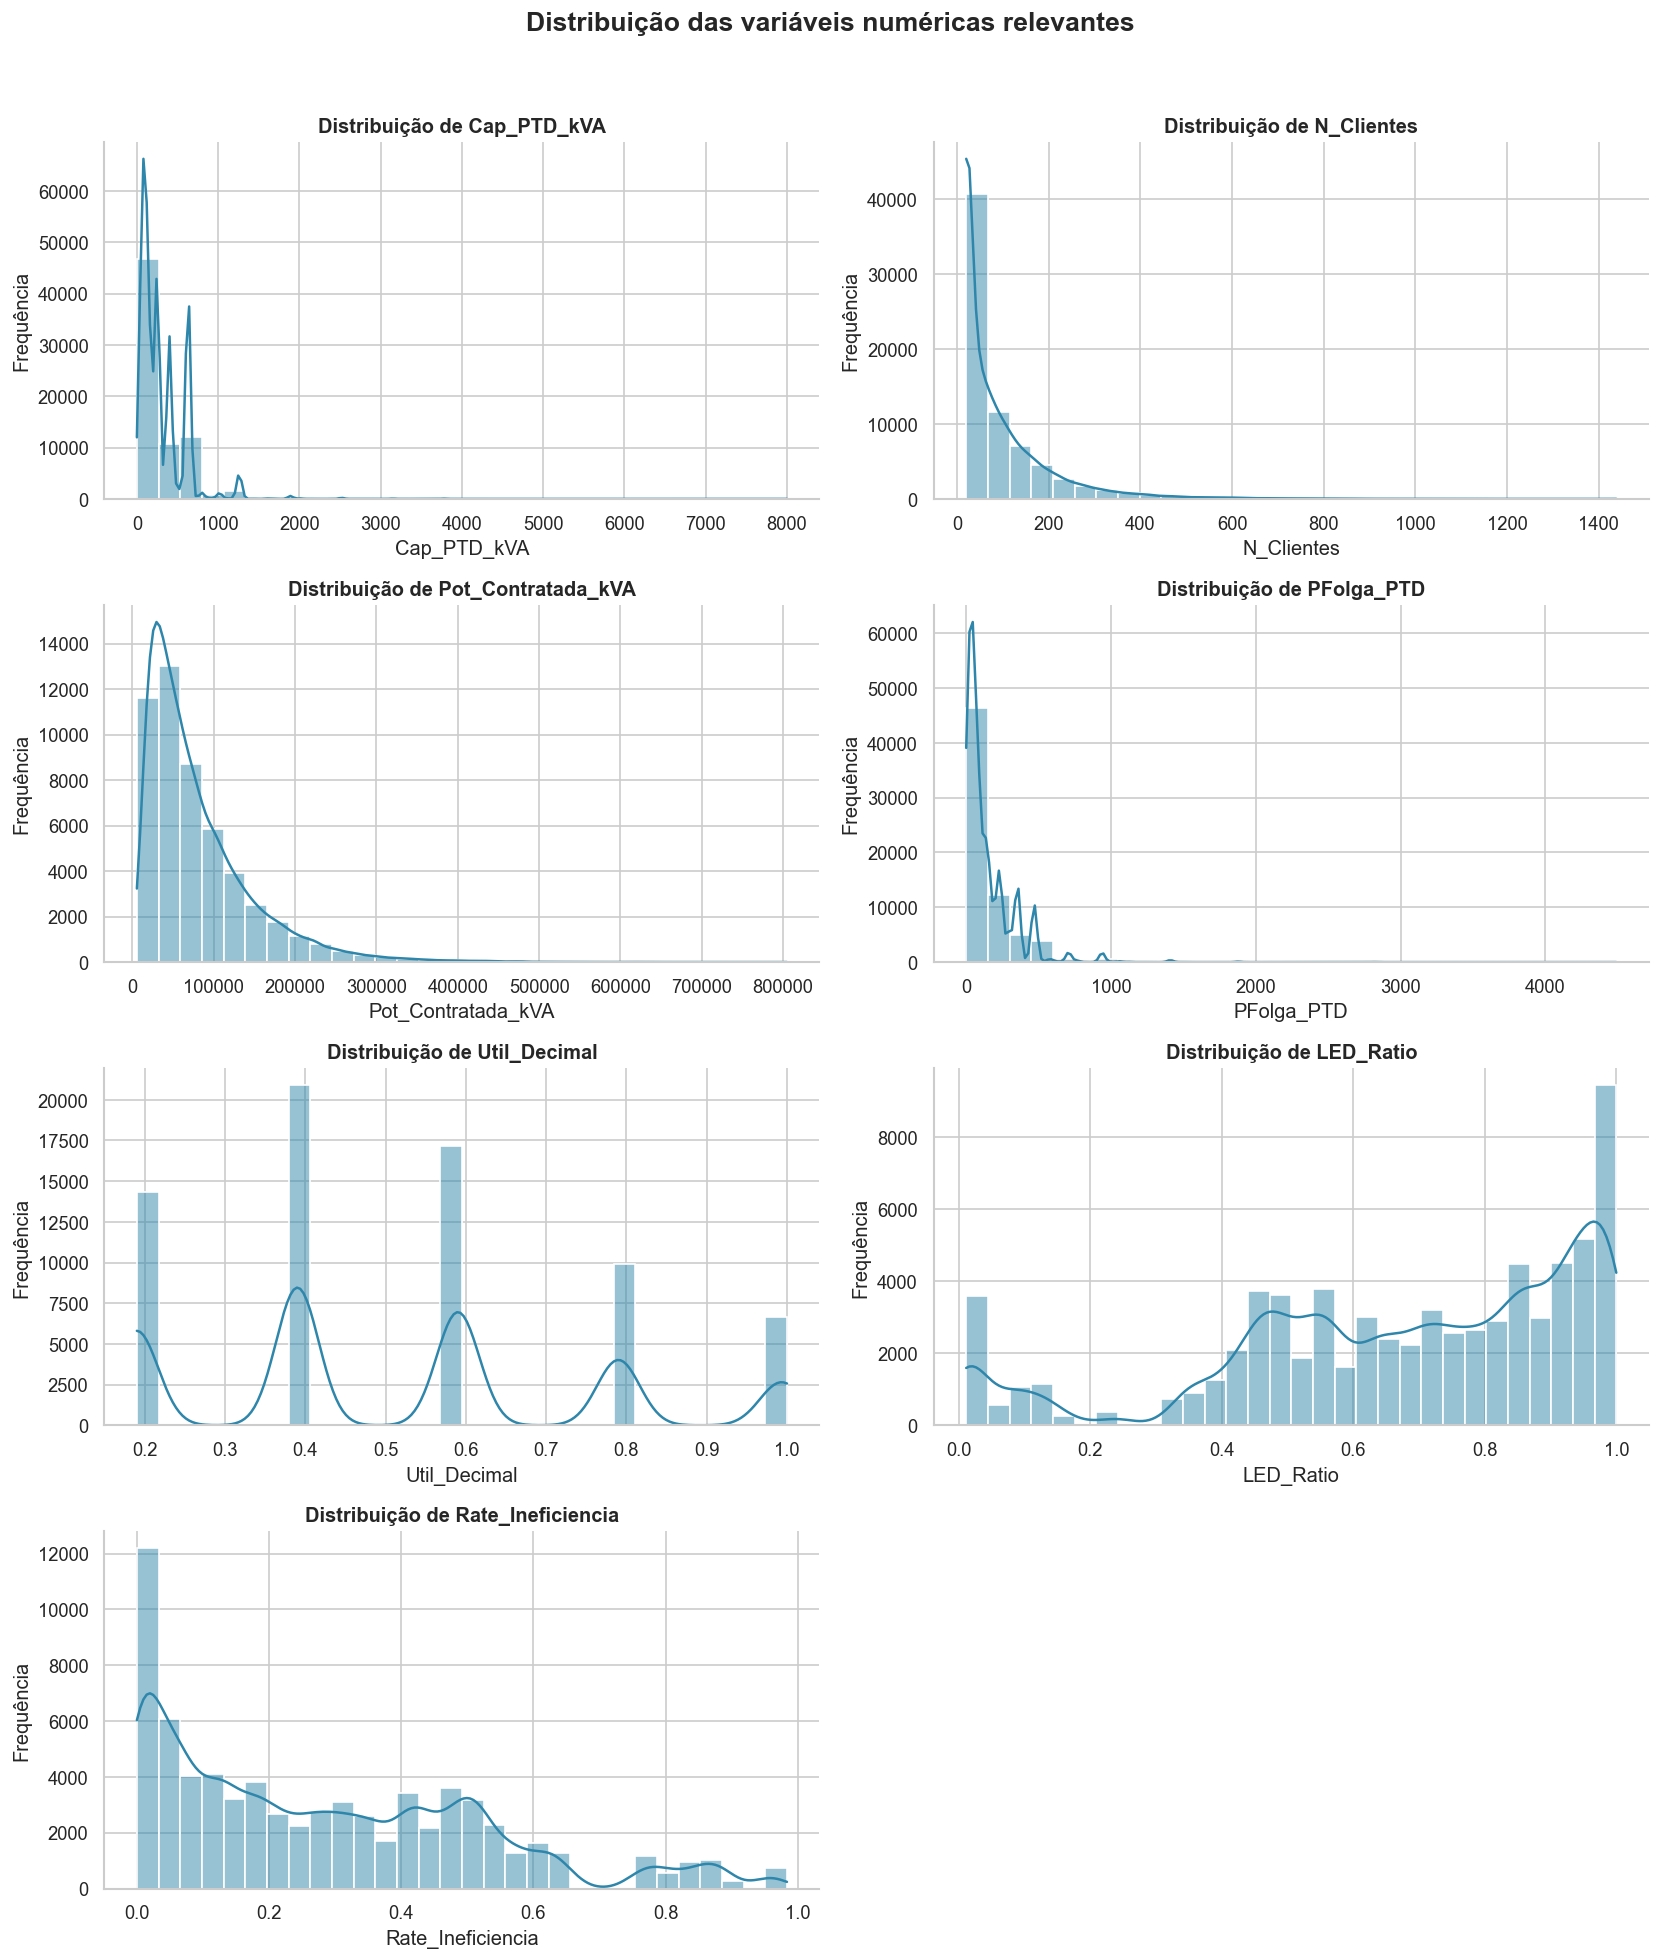

In [3]:
# Variáveis numéricas consideradas mais relevantes para a análise visual inicial
numeric_vars = [
    "Cap_PTD_kVA",
    "N_Clientes",
    "Pot_Contratada_kVA",
    "PFolga_PTD",
    "Util_Decimal",
    "LED_Ratio",
    "Rate_Ineficiencia"
]

# Apenas são usadas variáveis que existem no dataset, evitando erros caso algum nome não esteja disponível
numeric_vars = [var for var in numeric_vars if var in df.columns]

n_cols = 2
n_rows = int(np.ceil(len(numeric_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
fig.suptitle("Distribuição das variáveis numéricas relevantes", fontsize=16, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, var in zip(axes, numeric_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, color=COR_PRINCIPAL, edgecolor="white", ax=ax)
    ax.set_title(f"Distribuição de {var}", fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Frequência")
    sns.despine(ax=ax)

# Remove eixos vazios quando o número de variáveis não ocupa toda a grelha
for ax in axes[len(numeric_vars):]:
    ax.set_visible(False)

plt.tight_layout()
guardar_grafico(fig, "distribuicoes_variaveis_numericas.png")
plt.show()


A análise das **distribuições das variáveis numéricas** evidencia comportamentos distintos entre os atributos selecionados.

As variáveis **`Cap_PTD_kVA`**, **`N_Clientes`**, **`Pot_Contratada_kVA`** e **`PFolga_PTD`** apresentam **distribuições assimétricas à direita**, com grande concentração de observações em valores mais baixos e presença de **valores extremos**. Este comportamento indica que a maioria dos PTD possui capacidades, número de clientes, potência contratada e folga de potência relativamente reduzidos, existindo apenas um conjunto menor de PTD com valores muito superiores.

A variável **`PFolga_PTD`**, sendo a **variável alvo da tarefa de regressão**, apresenta uma distribuição bastante concentrada nos valores mais baixos, mas com **cauda longa**. Esta característica poderá influenciar o desempenho dos modelos, especialmente dos modelos sensíveis a **outliers**.

A variável **`Util_Decimal`** apresenta valores concentrados em **intervalos discretos**, sugerindo que resulta de uma categorização ou de níveis de utilização pré-definidos. Este comportamento é coerente com a sua futura utilização na tarefa de **classificação**.

Relativamente às variáveis associadas à **iluminação pública**, observa-se que **`LED_Ratio`** apresenta maior concentração em valores elevados, indicando que muitos concelhos já possuem uma percentagem significativa de **iluminação LED**. Por outro lado, **`Rate_Ineficiencia`** apresenta maior concentração em valores baixos, embora com alguma dispersão ao longo do intervalo.

De forma geral, estas distribuições indicam a necessidade de considerar **normalização** ou **standardização** antes da aplicação de modelos sensíveis à escala, como **SVM**, **KNN** e **redes neuronais**, bem como uma análise posterior de **outliers**.


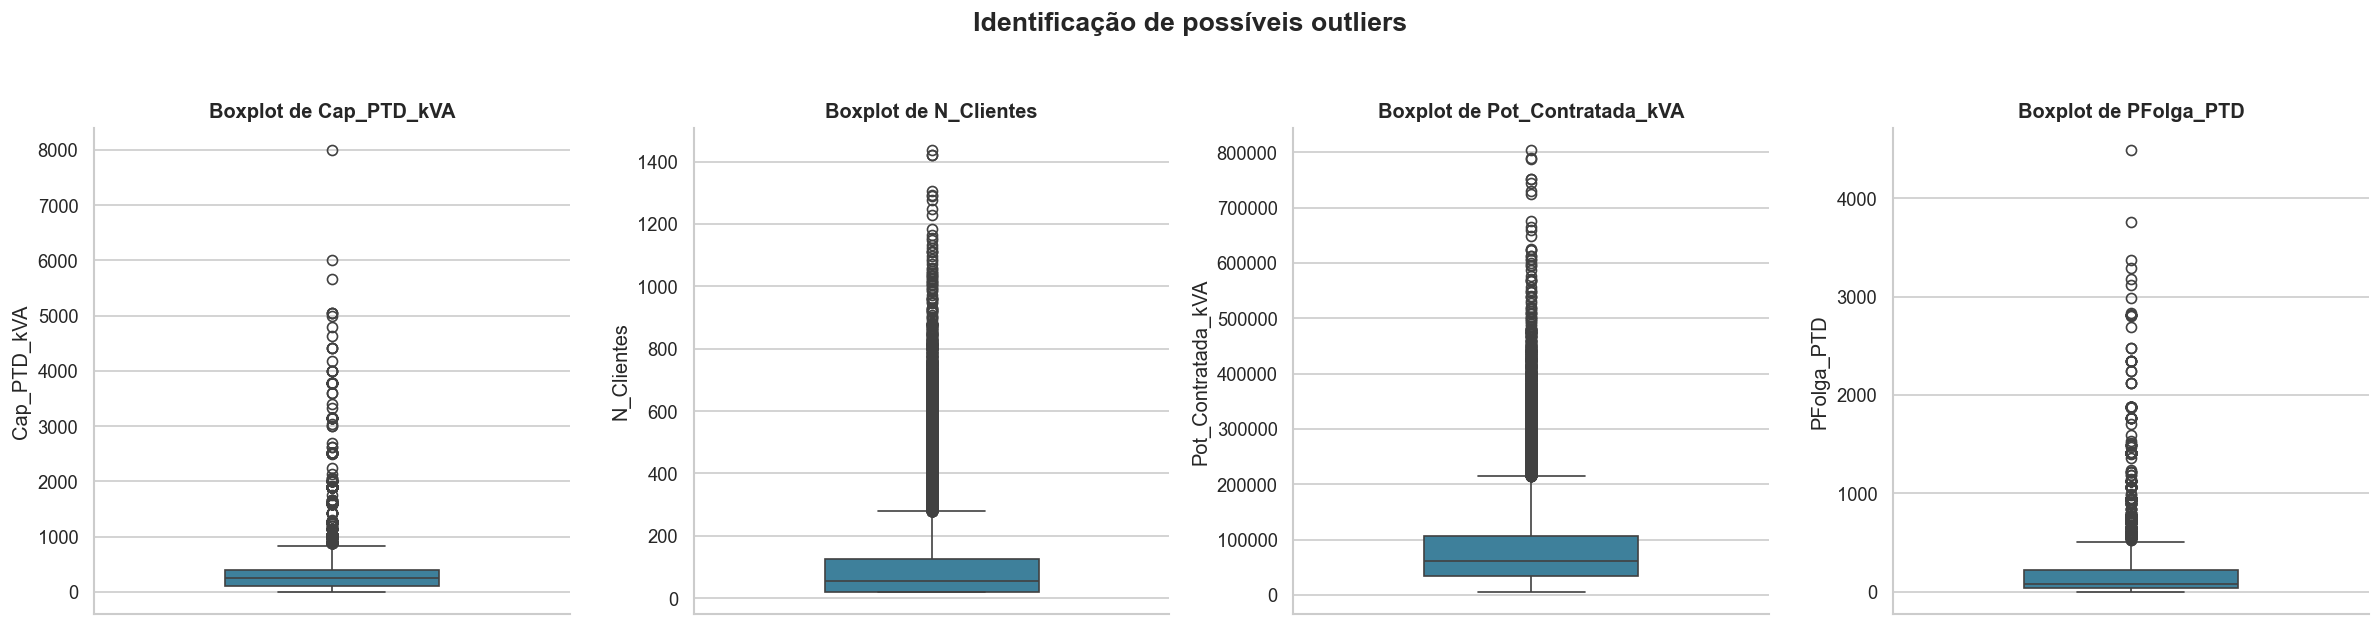

In [4]:
# Variáveis numéricas onde é particularmente útil procurar valores extremos
boxplot_vars = [
    "Cap_PTD_kVA",
    "N_Clientes",
    "Pot_Contratada_kVA",
    "PFolga_PTD"
]

boxplot_vars = [var for var in boxplot_vars if var in df.columns]

fig, axes = plt.subplots(1, len(boxplot_vars), figsize=(5 * len(boxplot_vars), 5))
fig.suptitle("Identificação de possíveis outliers", fontsize=16, fontweight="bold", y=1.04)

if len(boxplot_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, boxplot_vars):
    sns.boxplot(y=df[var].dropna(), color=COR_PRINCIPAL, width=0.45, ax=ax)
    ax.set_title(f"Boxplot de {var}", fontweight="bold")
    ax.set_ylabel(var)
    sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "boxplots_outliers_variaveis_numericas.png")
plt.show()


Os **boxplots** confirmam a presença de **valores extremos** nas principais variáveis numéricas analisadas.

Nas variáveis **`Cap_PTD_kVA`**, **`N_Clientes`** e **`Pot_Contratada_kVA`**, observa-se que a maioria dos registos se concentra em valores relativamente baixos, enquanto existem vários PTD com valores bastante superiores à distribuição central. Este comportamento é coerente com os histogramas analisados anteriormente e indica uma **forte assimetria à direita**.

A variável **`PFolga_PTD`**, sendo a **variável alvo da regressão**, também apresenta um número considerável de **valores extremos**. Isto sugere que alguns PTD possuem uma folga de potência muito superior à maioria, podendo influenciar o treino dos modelos e as métricas de erro.

Assim, estes resultados reforçam a necessidade de avaliar o impacto dos **outliers** no **pré-processamento** e na **modelação**. No entanto, estes valores não devem ser removidos automaticamente, uma vez que podem representar PTD reais com maior capacidade instalada ou menor nível de utilização.


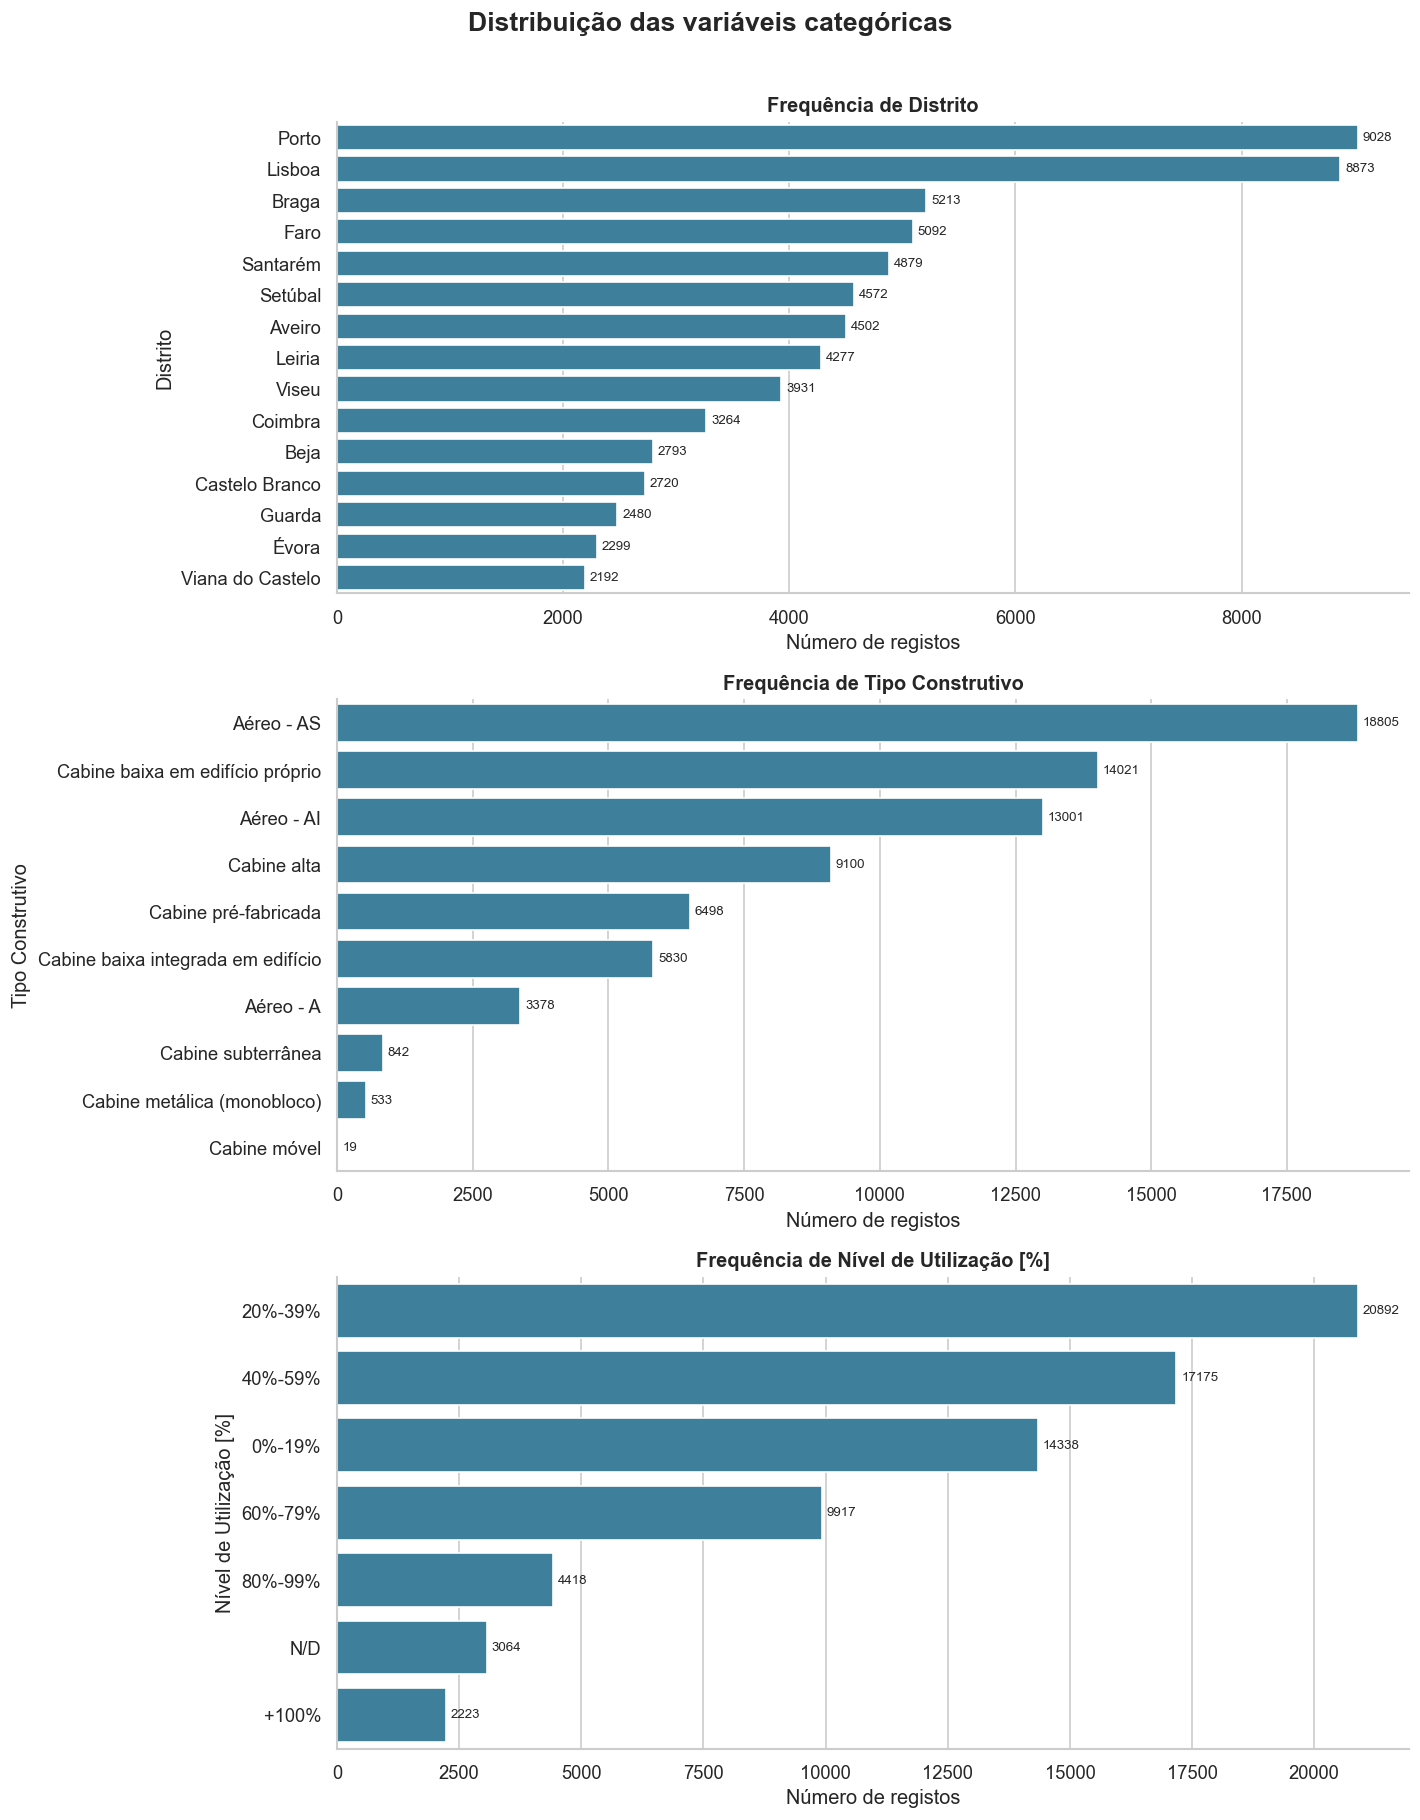

In [5]:
# Variáveis categóricas relevantes para perceber a composição do dataset
categorical_vars = [
    "Distrito",
    "Tipo Construtivo",
    "Nível de Utilização [%]"
]

categorical_vars = [var for var in categorical_vars if var in df.columns]

fig, axes = plt.subplots(len(categorical_vars), 1, figsize=(12, 5 * len(categorical_vars)))
fig.suptitle("Distribuição das variáveis categóricas", fontsize=16, fontweight="bold", y=1.01)

if len(categorical_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, categorical_vars):
    counts = df[var].dropna().value_counts()
    
    # Para Distrito, mostram-se apenas os 15 mais frequentes para manter o gráfico legível
    if var == "Distrito":
        counts = counts.head(15)
    
    sns.barplot(x=counts.values, y=counts.index, color=COR_PRINCIPAL, ax=ax)
    ax.set_title(f"Frequência de {var}", fontweight="bold")
    ax.set_xlabel("Número de registos")
    ax.set_ylabel(var)
    ax.bar_label(ax.containers[0], padding=3, fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "barras_variaveis_categoricas.png")
plt.show()


Os **gráficos de barras** permitem analisar a distribuição das **variáveis categóricas** e compreender a composição do dataset.

Relativamente à variável **`Distrito`**, observa-se uma maior concentração de registos em zonas como **Porto** e **Lisboa**, indicando uma maior representatividade destas regiões no dataset. Esta diferença pode influenciar os modelos, especialmente se existirem padrões regionais associados à utilização da rede ou à capacidade dos PTD.

Na variável **`Tipo Construtivo`**, verifica-se que os tipos **"Aéreo - AS"** e **"Cabine baixa em edifício próprio"** são os mais frequentes, enquanto outros tipos apresentam uma representatividade bastante reduzida. Esta desigualdade pode dificultar a aprendizagem de padrões para categorias menos representadas.

Por fim, a variável **`Nível de Utilização [%]`** mostra que a maioria dos PTD se encontra em níveis intermédios de utilização (**20%-39%** e **40%-59%**), sendo menos frequentes situações de utilização muito elevada. Este comportamento é relevante para a tarefa de **classificação**, pois indica uma **distribuição desequilibrada entre classes**.

De forma geral, estas distribuições sugerem a necessidade de considerar o impacto de **classes desbalanceadas** e avaliar a forma como as **variáveis categóricas** serão codificadas na fase de **pré-processamento**.


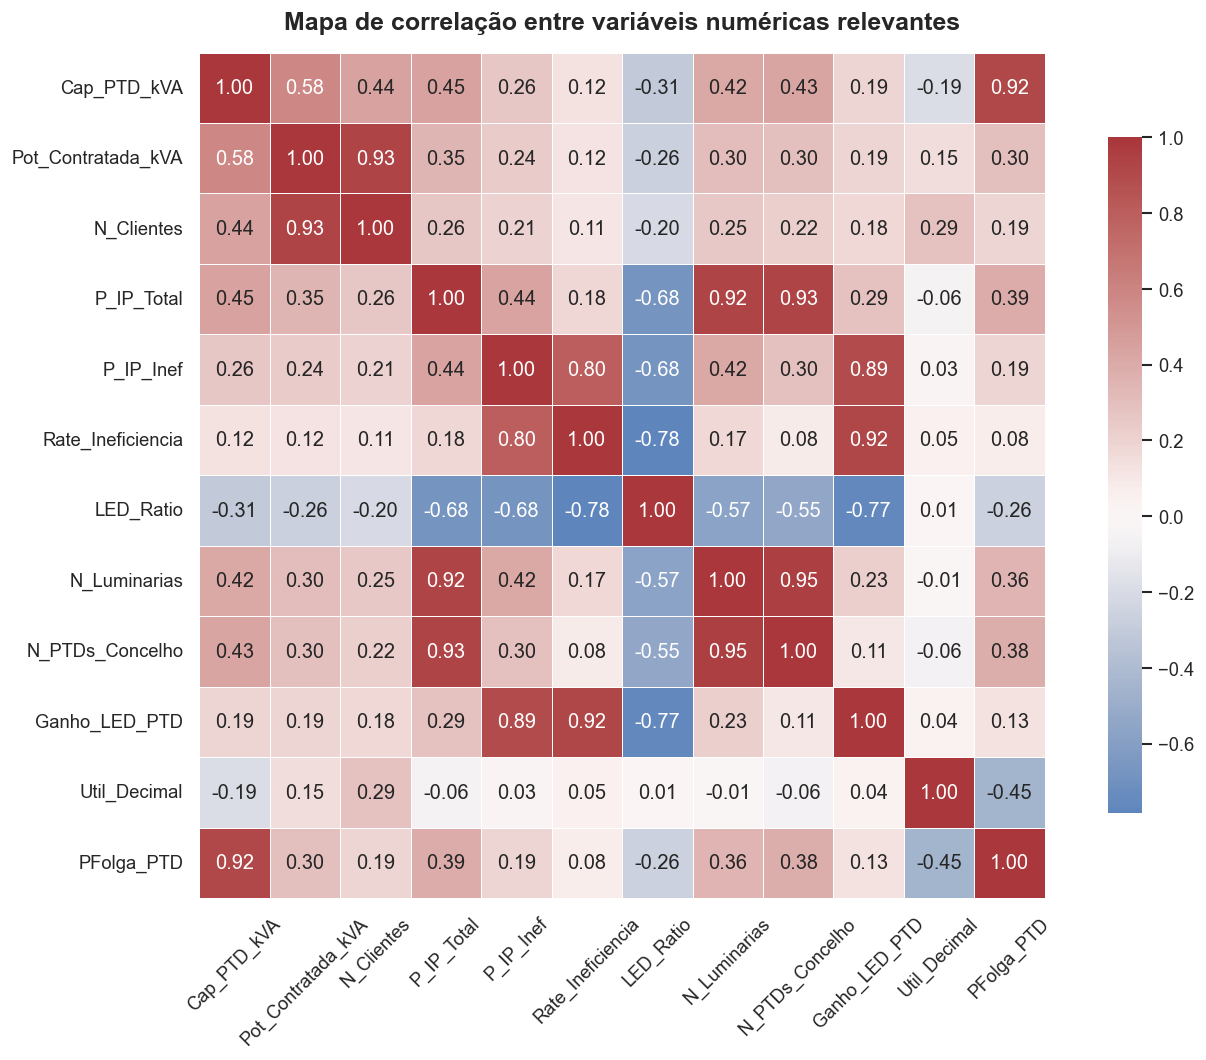

,Correlação com PFolga_PTD
Cap_PTD_kVA,0.915892
Util_Decimal,-0.452051
P_IP_Total,0.388398
N_PTDs_Concelho,0.383962
N_Luminarias,0.357481
Pot_Contratada_kVA,0.302577
LED_Ratio,-0.257265
N_Clientes,0.188011
P_IP_Inef,0.187407
Ganho_LED_PTD,0.129458


In [6]:
# Conjunto de variáveis numéricas usado para analisar relações lineares iniciais
corr_vars = [
    "Cap_PTD_kVA",
    "Pot_Contratada_kVA",
    "N_Clientes",
    "P_IP_Total",
    "P_IP_Inef",
    "Rate_Ineficiencia",
    "LED_Ratio",
    "N_Luminarias",
    "N_PTDs_Concelho",
    "Ganho_LED_PTD",
    "Util_Decimal",
    "PFolga_PTD"
]

corr_vars = [var for var in corr_vars if var in df.columns]
corr_matrix = df[corr_vars].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=PALETA_CORRELACAO,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Mapa de correlação entre variáveis numéricas relevantes", fontsize=15, fontweight="bold", pad=14)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
guardar_grafico(fig, "heatmap_correlacao_variaveis_numericas.png")
plt.show()

# Correlações ordenadas com a variável alvo da regressão
if "PFolga_PTD" in corr_matrix.columns:
    correlacoes_alvo = corr_matrix["PFolga_PTD"].drop("PFolga_PTD").sort_values(key=abs, ascending=False)
    display(correlacoes_alvo.to_frame("Correlação com PFolga_PTD"))


A análise das **correlações** com a variável alvo **`PFolga_PTD`** permite identificar de forma mais clara quais os fatores com maior influência na folga de potência.

Destaca-se uma **forte correlação positiva com `Cap_PTD_kVA` (≈ 0.92)**, confirmando que a capacidade instalada do PTD é o principal determinante da folga disponível. Esta relação é consistente com o funcionamento esperado da rede elétrica.

Observa-se também uma **correlação negativa moderada com `Util_Decimal` (≈ -0.45)**, indicando que níveis mais elevados de utilização da rede estão associados a menor folga de potência.

Adicionalmente, variáveis como **`P_IP_Total`**, **`N_PTDs_Concelho`** e **`N_Luminarias`** apresentam correlações positivas moderadas (≈ 0.35–0.39), sugerindo que a dimensão da infraestrutura elétrica e da iluminação pública tem impacto na disponibilidade de potência.

Por outro lado, variáveis como **`LED_Ratio`** apresentam correlação negativa (≈ -0.26), o que pode indicar que uma maior eficiência energética está associada a uma redistribuição da carga na rede.

De forma geral, estas correlações permitem identificar variáveis com maior **potencial preditivo** para a modelação da **`PFolga_PTD`**, bem como suportar decisões futuras de **seleção de variáveis** e **redução de redundância entre atributos**.


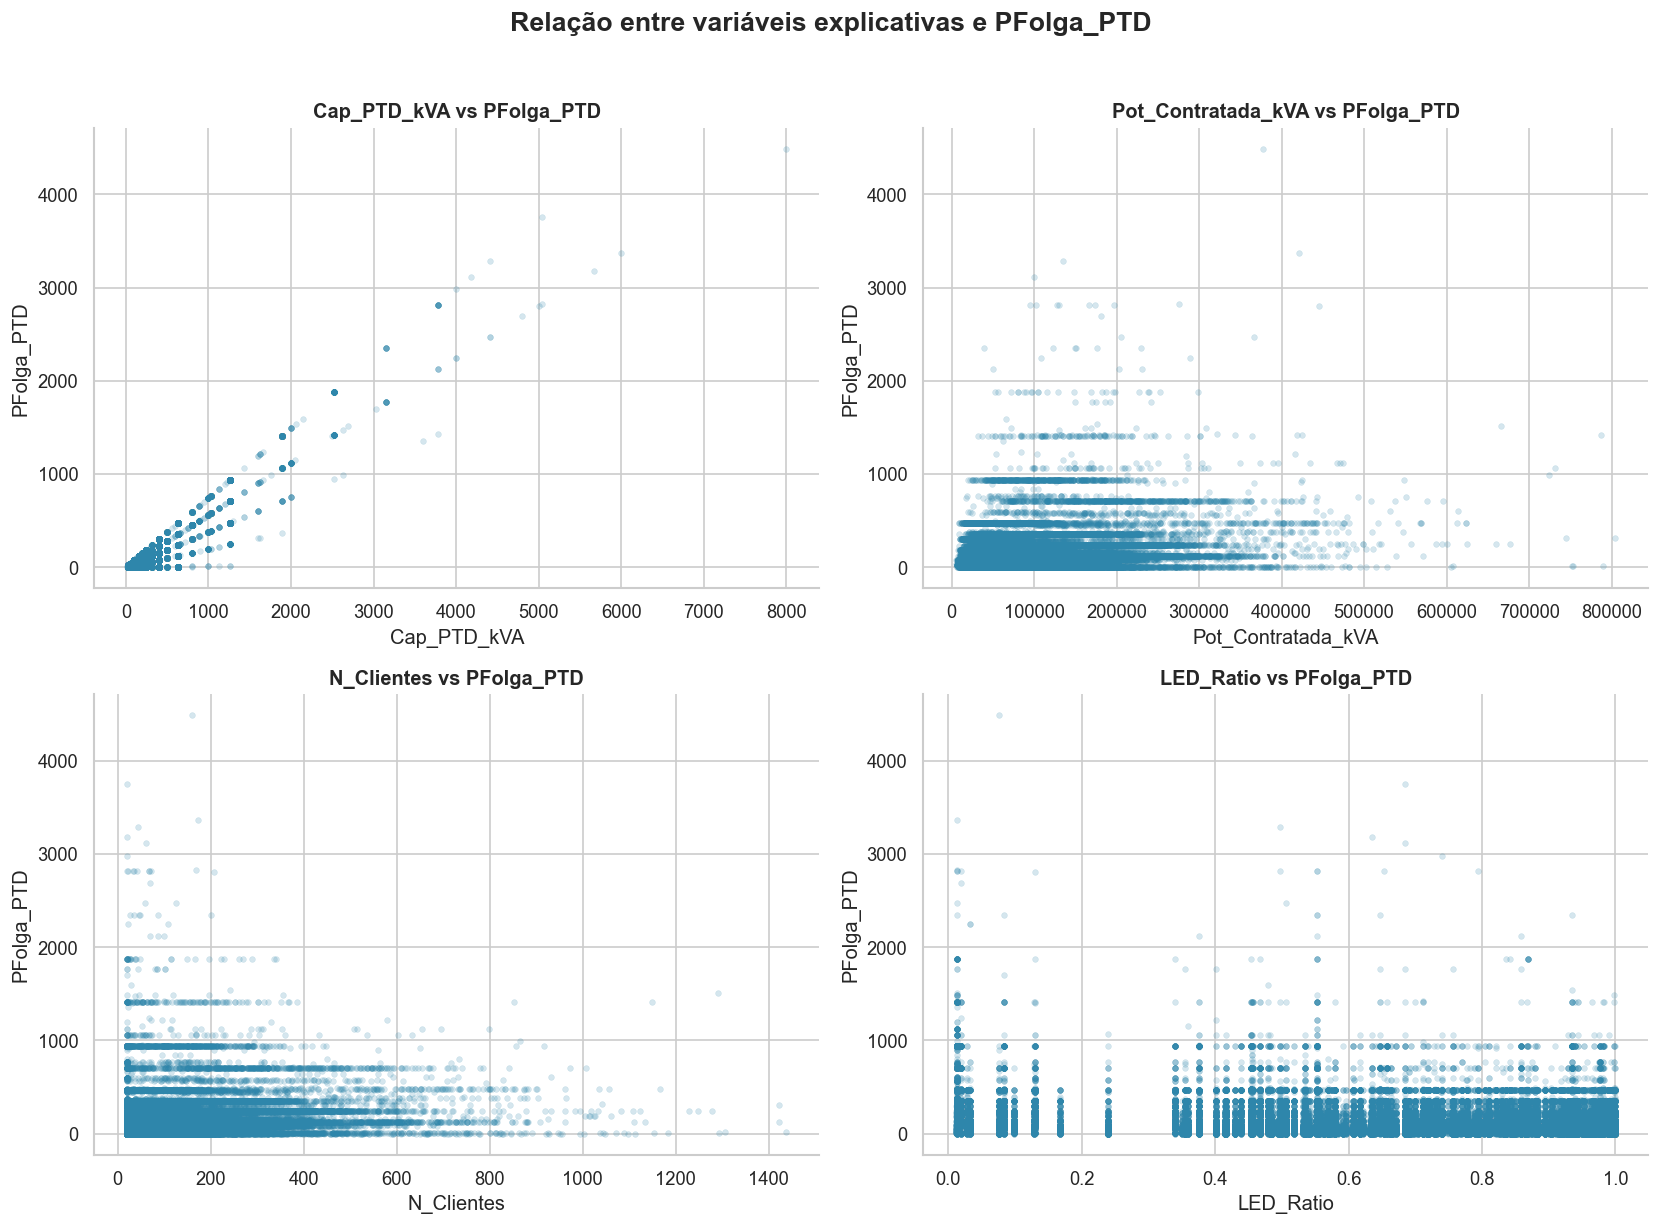

In [7]:
# Relações entre variáveis explicativas e a variável alvo da regressão
target = "PFolga_PTD"
scatter_vars = [
    "Cap_PTD_kVA",
    "Pot_Contratada_kVA",
    "N_Clientes",
    "LED_Ratio"
]

scatter_vars = [var for var in scatter_vars if var in df.columns and target in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Relação entre variáveis explicativas e PFolga_PTD", fontsize=16, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, var in zip(axes, scatter_vars):
    plot_data = df[[var, target]].dropna()
    sns.scatterplot(data=plot_data, x=var, y=target, alpha=0.20, s=12, color=COR_PRINCIPAL, edgecolor=None, ax=ax)
    ax.set_title(f"{var} vs {target}", fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel(target)
    sns.despine(ax=ax)

for ax in axes[len(scatter_vars):]:
    ax.set_visible(False)

plt.tight_layout()
guardar_grafico(fig, "scatter_relacoes_com_pfolga_ptd.png")
plt.show()


Os **gráficos de dispersão** permitem analisar a relação entre algumas **variáveis explicativas** e a variável alvo **`PFolga_PTD`**.

Observa-se uma **relação claramente positiva entre `Cap_PTD_kVA` e `PFolga_PTD`**, indicando que PTD com maior capacidade instalada tendem a apresentar maior folga de potência. Esta relação é aproximadamente linear e confirma os resultados obtidos na análise de correlação.

No caso da variável **`Pot_Contratada_kVA`**, a relação com **`PFolga_PTD`** é menos evidente e apresenta maior dispersão. Embora existam alguns valores elevados de folga associados a maiores níveis de potência contratada, não se observa um padrão linear claro, sugerindo uma relação mais fraca.

Para a variável **`N_Clientes`**, verifica-se uma tendência geral de diminuição da folga de potência à medida que o número de clientes aumenta, embora com elevada variabilidade. Este comportamento é consistente com a ideia de que maior número de consumidores implica maior utilização da rede.

Relativamente à variável **`LED_Ratio`**, não se observa uma relação linear clara com **`PFolga_PTD`**. No entanto, nota-se uma maior concentração de valores em intervalos mais elevados de eficiência (valores próximos de 1), o que poderá indicar que a eficiência energética, embora relevante, não é por si só suficiente para explicar a variabilidade da folga.

De forma geral, estes resultados confirmam que a variável **`Cap_PTD_kVA`** é a mais relevante para a previsão da **`PFolga_PTD`**, enquanto as restantes variáveis apresentam relações mais fracas ou não lineares. Esta análise reforça a importância da **seleção de variáveis** e da escolha de **modelos adequados** nas fases seguintes do trabalho.


### 4.1.3 Pré-processamento dos dados

Após a análise exploratória, procede-se ao pré-processamento dos dados, etapa essencial antes da aplicação de modelos de aprendizagem automática. Esta fase tem como objetivo preparar o dataset para que possa ser utilizado de forma adequada pelos algoritmos, corrigindo problemas identificados na análise exploratória e garantindo maior qualidade na modelação.

Tal como abordado na componente teórica, os modelos de aprendizagem automática não devem receber os dados diretamente no seu formato original quando estes incluem valores omissos, variáveis categóricas, atributos em escalas muito diferentes ou variáveis sem significado preditivo. Estes aspetos podem afetar o desempenho dos modelos, originar erros durante o treino ou comprometer a capacidade de generalização.

Nesta fase são consideradas quatro etapas principais:

- tratamento de valores omissos, de forma a evitar erros no treino dos modelos e reduzir perda desnecessária de observações;
- transformação de variáveis categóricas, permitindo que informação originalmente textual possa ser utilizada por algoritmos de aprendizagem automática;
- normalização ou standardização das variáveis numéricas, especialmente relevante para modelos sensíveis à escala, como KNN, SVM e redes neuronais;
- seleção de variáveis relevantes, removendo identificadores, variáveis redundantes, atributos com demasiados valores em falta e variáveis diretamente relacionadas com a variável alvo.

Como o trabalho inclui duas tarefas principais, regressão e classificação, o pré-processamento será organizado de forma a produzir bases adequadas para ambas. Para a tarefa de regressão, considera-se como variável alvo `PFolga_PTD`, correspondente à folga de potência disponível por PTD. Para a tarefa de classificação, será posteriormente criada a variável `utilizRede`, derivada de `Util_Decimal`, representando o nível de utilização da rede em três classes: baixo, médio e alto.


In [8]:
# Definição das variáveis alvo das duas tarefas de aprendizagem automática
target_regressao = "PFolga_PTD"

# A variável alvo da classificação será criada posteriormente a partir de Util_Decimal
target_classificacao = "utilizRede"
variavel_base_classificacao = "Util_Decimal"


# Variáveis removidas por não serem adequadas à modelação direta
variaveis_identificacao = [
    "Código de Instalação",       # identificador único do PTD
    "Coordenadas Geográficas",    # texto com coordenadas; exigiria tratamento geográfico específico
    "CodDistritoConcelho"         # código administrativo, redundante com informação regional
]


# Variáveis categóricas com elevada cardinalidade
# A variável Concelho apresenta muitas categorias distintas, podendo tornar o modelo demasiado específico
variaveis_alta_cardinalidade = [
    "Concelho"
]


# Variáveis removidas devido à elevada percentagem de valores omissos
variaveis_muita_omissao = [
    "Pot_Geracao_kW",             # cerca de 97% de valores em falta
    "Geracao_per_Cliente"         # cerca de 97% de valores em falta
]


# Variáveis redundantes ou com baixo poder discriminativo
variaveis_redundantes = [
    "Potência instalada [kVA]",   # duplica a informação de Cap_PTD_kVA
    "N_Lampadas",                 # muito próxima de N_Luminarias
    "PVE_PTD"                     # variável constante, sem poder discriminativo
]


# Variáveis diretamente relacionadas com a variável alvo da regressão ou derivadas da utilização/folga.
# São removidas das variáveis explicativas para evitar resultados artificialmente elevados.
variaveis_relacionadas_alvo_regressao = [
    "D_PTD",
    "D_PTD_LED",
    "Util_Decimal",
    "Nível de Utilização [%]"
]


# Variáveis relacionadas com a variável alvo da classificação.
# Util_Decimal será usada para criar a variável alvo utilizRede, mas não deve entrar como input do modelo.
variaveis_relacionadas_alvo_classificacao = [
    "Util_Decimal",
    "Nível de Utilização [%]",
    "PFolga_PTD",
    "D_PTD",
    "D_PTD_LED"
]


# Variáveis selecionadas para representar capacidade, consumo, clientes,
# iluminação pública, eficiência e contexto regional.
variaveis_selecionadas_base = [
    "Distrito",
    "Tipo Construtivo",
    "Cap_PTD_kVA",
    "Pot_Contratada_kVA",
    "PContratada_per_Cliente",
    "N_Clientes",
    "N_Clientes_Produtores",
    "P_IP_Total",
    "P_IP_Inef",
    "Rate_Ineficiencia",
    "LED_Ratio",
    "N_Luminarias",
    "N_PTDs_Concelho",
    "IP_per_PTD",
    "IP_Inef_per_PTD",
    "Ganho_LED_PTD"
]


# Garante que apenas são usadas variáveis existentes no dataset
variaveis_selecionadas_base = [var for var in variaveis_selecionadas_base if var in df.columns]


# Tabela-resumo com os principais critérios de remoção
criterios_remocao = pd.DataFrame({
    "Grupo": (
        ["Identificação"] * len(variaveis_identificacao)
        + ["Alta cardinalidade"] * len(variaveis_alta_cardinalidade)
        + ["Muita omissão"] * len(variaveis_muita_omissao)
        + ["Redundância/constante"] * len(variaveis_redundantes)
        + ["Relacionada com a variável alvo - regressão"] * len(variaveis_relacionadas_alvo_regressao)
        + ["Relacionada com a variável alvo - classificação"] * len(variaveis_relacionadas_alvo_classificacao)
    ),
    "Variável": (
        variaveis_identificacao
        + variaveis_alta_cardinalidade
        + variaveis_muita_omissao
        + variaveis_redundantes
        + variaveis_relacionadas_alvo_regressao
        + variaveis_relacionadas_alvo_classificacao
    )
})

print("Variáveis selecionadas como base para modelação:")
display(pd.DataFrame({"Variável": variaveis_selecionadas_base}))

print("Principais variáveis removidas e respetivo critério:")
display(criterios_remocao)


Variáveis selecionadas como base para modelação:


,Variável
0,Distrito
1,Tipo Construtivo
2,Cap_PTD_kVA
3,Pot_Contratada_kVA
4,PContratada_per_Cliente
5,N_Clientes
6,N_Clientes_Produtores
7,P_IP_Total
8,P_IP_Inef
9,Rate_Ineficiencia


Principais variáveis removidas e respetivo critério:


,Grupo,Variável
0,Identificação,Código de Instalação
1,Identificação,Coordenadas Geográficas
2,Identificação,CodDistritoConcelho
3,Alta cardinalidade,Concelho
4,Muita omissão,Pot_Geracao_kW
5,Muita omissão,Geracao_per_Cliente
6,Redundância/constante,Potência instalada [kVA]
7,Redundância/constante,N_Lampadas
8,Redundância/constante,PVE_PTD
9,Relacionada com a variável alvo - regressão,D_PTD


Nesta etapa foram definidos os principais critérios de seleção e exclusão de variáveis para a modelação. Foram removidas variáveis identificadoras, variáveis com elevada percentagem de valores omissos, atributos redundantes ou constantes e variáveis diretamente relacionadas com a variável alvo, que poderiam originar resultados artificialmente elevados.

A variável `Concelho` foi excluída devido à sua elevada cardinalidade, uma vez que a existência de muitas categorias poderia tornar os modelos demasiado específicos e reduzir a sua capacidade de generalização. Em alternativa, mantém-se a variável `Distrito`, que permite representar informação regional de forma menos granular.

Para a tarefa de regressão, a variável alvo será `PFolga_PTD`. Para a tarefa de classificação, será criada posteriormente a variável `utilizRede` a partir de `Util_Decimal`, pelo que esta última não deverá ser utilizada como variável explicativa nos modelos de classificação.


In [9]:
def preparar_base_inicial(dados, variaveis_explicativas, alvo):
    """
    Cria uma base inicial com as variáveis explicativas selecionadas e a variável alvo.
    Nesta fase são removidas apenas as linhas em que a variável alvo está em falta.
    """
    colunas = variaveis_explicativas + [alvo]
    colunas = [col for col in colunas if col in dados.columns]

    base = dados[colunas].copy()
    base = base.dropna(subset=[alvo])

    return base


# Base inicial para regressão
base_regressao = preparar_base_inicial(
    df,
    variaveis_selecionadas_base,
    target_regressao
)

print(
    f"Base de regressão após remover linhas sem alvo: "
    f"{base_regressao.shape[0]} linhas e {base_regressao.shape[1]} colunas"
)


# Criação da variável alvo da classificação a partir de Util_Decimal
df_classificacao = df.copy()

df_classificacao["utilizRede"] = pd.qcut(
    df_classificacao["Util_Decimal"],
    q=3,
    labels=["baixo", "médio", "alto"],
    duplicates="drop"
)

print("Distribuição da variável utilizRede:")
display(df_classificacao["utilizRede"].value_counts(dropna=False).to_frame("Frequência"))

display(
    (df_classificacao["utilizRede"].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentagem (%)")
)


# Base inicial para classificação
base_classificacao = preparar_base_inicial(
    df_classificacao,
    variaveis_selecionadas_base,
    target_classificacao
)

print(
    f"Base de classificação após remover linhas sem alvo: "
    f"{base_classificacao.shape[0]} linhas e {base_classificacao.shape[1]} colunas"
)


# Percentagem de valores omissos nas variáveis selecionadas para regressão
missing_regressao = pd.DataFrame({
    "Valores em falta": base_regressao[variaveis_selecionadas_base].isnull().sum(),
    "Percentagem (%)": (base_regressao[variaveis_selecionadas_base].isnull().mean() * 100).round(2)
}).sort_values("Valores em falta", ascending=False)

print("Valores omissos nas variáveis explicativas selecionadas para regressão:")
display(missing_regressao[missing_regressao["Valores em falta"] > 0])


Base de regressão após remover linhas sem alvo: 68963 linhas e 17 colunas
Distribuição da variável utilizRede:


,Frequência
utilizRede,
baixo,35230
médio,17175
alto,16558
NaN,3064


,Percentagem (%)
utilizRede,
baixo,48.91
médio,23.85
alto,22.99
NaN,4.25


Base de classificação após remover linhas sem alvo: 68963 linhas e 17 colunas
Valores omissos nas variáveis explicativas selecionadas para regressão:


,Valores em falta,Percentagem (%)
Pot_Contratada_kVA,19392,28.12
PContratada_per_Cliente,19392,28.12


A variável `utilizRede` foi criada a partir de `Util_Decimal` recorrendo à discretização por quantis, originando três classes: baixo, médio e alto. Esta opção permite obter uma distribuição das classes mais controlada para a tarefa de classificação. Devido à existência de valores repetidos em `Util_Decimal`, as classes não ficam exatamente com a mesma dimensão, mas continuam mais adequadas para modelação do que uma divisão arbitrária sem considerar a distribuição dos dados.

A tabela de frequências permite confirmar a distribuição da variável criada. As observações sem valor em `Util_Decimal` ficam sem classe em `utilizRede` e são removidas antes da construção da base de classificação, uma vez que não é possível treinar um modelo supervisionado com a variável alvo em falta.

Após a remoção das observações sem valor na variável alvo, as bases iniciais de regressão e classificação ficaram ambas com 68.963 registos e 17 colunas. Esta remoção é necessária porque, em modelos supervisionados, não é possível treinar nem avaliar corretamente um modelo sem conhecer o valor real da variável a prever.

A análise dos valores omissos nas variáveis explicativas selecionadas mostra que as omissões restantes se concentram em `Pot_Contratada_kVA` e `PContratada_per_Cliente`, ambas com 19.392 valores em falta, correspondendo a 28,12% da base de regressão.

Para tratar estes valores omissos, será adotada uma estratégia simples e robusta:

- nas variáveis numéricas, os valores em falta serão substituídos pela mediana, por esta ser menos sensível à presença de outliers do que a média;
- nas variáveis categóricas, os valores em falta serão substituídos pela moda, ou seja, pela categoria mais frequente;
- nas variáveis alvo, as linhas sem valor foram removidas, uma vez que não é possível utilizar observações sem resposta conhecida em modelos supervisionados.

Esta abordagem permite obter uma base completa, consistente e adequada à aplicação dos algoritmos de aprendizagem automática, reduzindo a perda de observações e evitando imputações excessivamente influenciadas por valores extremos.


In [10]:
def imputar_valores_omissos(base, alvo):
    """
    Imputa valores omissos nas variáveis explicativas, mantendo a variável alvo separada.

    Estratégia utilizada:
    - variáveis numéricas: imputação pela mediana;
    - variáveis categóricas: imputação pela moda.
    """
    base_imputada = base.copy()

    # Separação entre variáveis explicativas e variável alvo
    variaveis_explicativas = [col for col in base_imputada.columns if col != alvo]

    # Identificação automática das variáveis numéricas e categóricas
    variaveis_numericas = (
        base_imputada[variaveis_explicativas]
        .select_dtypes(include="number")
        .columns
        .tolist()
    )

    variaveis_categoricas = (
        base_imputada[variaveis_explicativas]
        .select_dtypes(exclude="number")
        .columns
        .tolist()
    )

    # Imputação das variáveis numéricas pela mediana
    for var in variaveis_numericas:
        mediana = base_imputada[var].median()
        base_imputada[var] = base_imputada[var].fillna(mediana)

    # Imputação das variáveis categóricas pela moda
    for var in variaveis_categoricas:
        moda = base_imputada[var].mode(dropna=True)
        if not moda.empty:
            base_imputada[var] = base_imputada[var].fillna(moda.iloc[0])

    return base_imputada, variaveis_numericas, variaveis_categoricas


# Aplicação da imputação às bases de regressão e classificação
base_regressao_imputada, numericas_reg, categoricas_reg = imputar_valores_omissos(
    base_regressao,
    target_regressao
)

base_classificacao_imputada, numericas_clf, categoricas_clf = imputar_valores_omissos(
    base_classificacao,
    target_classificacao
)


# Resumo da imputação realizada
resumo_imputacao = pd.DataFrame({
    "Base": ["Regressão", "Classificação"],
    "Valores em falta após imputação": [
        base_regressao_imputada.drop(columns=[target_regressao]).isnull().sum().sum(),
        base_classificacao_imputada.drop(columns=[target_classificacao]).isnull().sum().sum()
    ],
    "Variáveis numéricas": [len(numericas_reg), len(numericas_clf)],
    "Variáveis categóricas": [len(categoricas_reg), len(categoricas_clf)]
})

display(resumo_imputacao)


,Base,Valores em falta após imputação,Variáveis numéricas,Variáveis categóricas
0,Regressão,0,14,2
1,Classificação,0,14,2


Após a imputação dos valores omissos, verifica-se que as bases de regressão e classificação deixam de apresentar valores em falta nas variáveis explicativas. Cada base mantém 14 variáveis numéricas e 2 variáveis categóricas, permitindo avançar para a transformação dos dados para um formato compatível com os algoritmos de aprendizagem automática.

As variáveis categóricas `Distrito` e `Tipo Construtivo` são transformadas através de one-hot encoding, criando colunas binárias para representar cada categoria. Esta abordagem é adequada porque se trata de variáveis nominais, isto é, variáveis sem uma ordem natural entre os seus valores. Assim, evita-se introduzir uma ordenação artificial que poderia influenciar incorretamente os modelos.

As variáveis numéricas são standardizadas através do z-score:

$$
z = \frac{x - \mu}{\sigma}
$$

Com esta transformação, cada variável passa a ter média aproximadamente 0 e desvio-padrão aproximadamente 1. A standardização é particularmente relevante para modelos sensíveis à escala das variáveis, como KNN, SVM e redes neuronais. Embora não seja obrigatória para modelos baseados em árvores de decisão, a utilização de uma base standardizada facilita a aplicação e comparação de diferentes algoritmos no mesmo processo experimental.


In [11]:
def codificar_e_standardizar(base, alvo):
    """
    Aplica one-hot encoding às variáveis categóricas e standardização às variáveis numéricas.

    Nota:
    Esta preparação cria uma base geral para exploração e modelação inicial.
    Na fase de treino e validação dos modelos, a standardização deverá ser
    aplicada manualmente em cada divisão de treino e validação para evitar contaminação entre treino e teste.
    """
    X = base.drop(columns=[alvo]).copy()
    y = base[alvo].copy()

    variaveis_numericas = X.select_dtypes(include="number").columns.tolist()
    variaveis_categoricas = X.select_dtypes(exclude="number").columns.tolist()

    # Standardização das variáveis numéricas
    X_numericas = X[variaveis_numericas].copy()
    medias = X_numericas.mean()
    desvios = X_numericas.std().replace(0, 1)
    X_numericas_std = (X_numericas - medias) / desvios

    # Transformação das variáveis categóricas em variáveis binárias
    X_categoricas_encoded = pd.get_dummies(
        X[variaveis_categoricas],
        columns=variaveis_categoricas,
        drop_first=False,
        dtype=int
    )

    # Construção da base final preparada
    X_preparado = pd.concat([X_numericas_std, X_categoricas_encoded], axis=1)
    base_preparada = pd.concat([X_preparado, y], axis=1)

    return base_preparada, X_preparado, y, variaveis_numericas, variaveis_categoricas


# Preparação da base de regressão
base_regressao_preparada, X_regressao, y_regressao, numericas_reg, categoricas_reg = codificar_e_standardizar(
    base_regressao_imputada,
    target_regressao
)

# Preparação da base de classificação
base_classificacao_preparada, X_classificacao, y_classificacao, numericas_clf, categoricas_clf = codificar_e_standardizar(
    base_classificacao_imputada,
    target_classificacao
)


# Resumo das bases preparadas
resumo_preprocessamento = pd.DataFrame({
    "Base": ["Regressão", "Classificação"],
    "Observações": [
        base_regressao_preparada.shape[0],
        base_classificacao_preparada.shape[0]
    ],
    "Variáveis explicativas após encoding": [
        X_regressao.shape[1],
        X_classificacao.shape[1]
    ],
    "Variável alvo": [
        target_regressao,
        target_classificacao
    ]
})

print("Resumo das bases preparadas para modelação:")
display(resumo_preprocessamento)

print("Primeiras linhas da base preparada para regressão:")
display(base_regressao_preparada.head())


Resumo das bases preparadas para modelação:


,Base,Observações,Variáveis explicativas após encoding,Variável alvo
0,Regressão,68963,41,PFolga_PTD
1,Classificação,68963,41,utilizRede


Primeiras linhas da base preparada para regressão:


,Cap_PTD_kVA,Pot_Contratada_kVA,PContratada_per_Cliente,N_Clientes,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,...,Tipo Construtivo_Aéreo - A,Tipo Construtivo_Aéreo - AI,Tipo Construtivo_Aéreo - AS,Tipo Construtivo_Cabine alta,Tipo Construtivo_Cabine baixa em edifício próprio,Tipo Construtivo_Cabine baixa integrada em edifício,Tipo Construtivo_Cabine metálica (monobloco),Tipo Construtivo_Cabine pré-fabricada,Tipo Construtivo_Cabine subterrânea,PFolga_PTD
0,0.335145,0.514715,0.417858,0.311466,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,0,0,0,0,0,1,0,77.28
1,-0.185529,0.033402,-0.065220,0.167233,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,0,0,0,1,0,0,0,48.30
2,-0.185529,0.604043,-0.239460,0.717122,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,0,1,0,0,0,0,0,48.30
3,-0.879761,-0.898264,-0.112902,-0.544919,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,0,1,0,0,0,0,0,0,0.00
4,-0.185529,-0.255726,-0.164960,-0.022073,-0.10277,-0.045968,0.739775,1.979336,-1.576701,-0.031737,...,0,1,0,0,0,0,0,0,0,186.30


Após a codificação e standardização, as bases de regressão e classificação mantêm 68.963 observações e passam a conter 41 variáveis explicativas. O aumento do número de variáveis deve-se à aplicação de one-hot encoding às variáveis categóricas `Distrito` e `Tipo Construtivo`, que foram convertidas em variáveis binárias.

A standardização foi aplicada às variáveis numéricas, colocando-as numa escala comum, com média aproximadamente 0 e desvio-padrão aproximadamente 1. Esta transformação é relevante porque várias variáveis apresentavam escalas muito diferentes, como observado na análise exploratória, e alguns modelos estudados, como KNN, SVM e redes neuronais, são sensíveis à escala dos atributos.

Assim, esta etapa permitiu transformar as variáveis explicativas para um formato totalmente numérico, sem valores omissos e mais adequado à aplicação dos algoritmos de aprendizagem automática. No entanto, na avaliação formal dos modelos, estas transformações deverão ser repetidas manualmente em cada divisão de treino e validação, de forma a evitar que estatísticas calculadas sobre todo o dataset influenciem os resultados da validação cruzada.


Por fim, são guardadas duas bases preparadas de referência, uma para a tarefa de regressão e outra para a tarefa de classificação. Estas bases resultam das etapas de seleção de variáveis, imputação, codificação das variáveis categóricas e standardização das variáveis numéricas.

A exportação destes ficheiros permite documentar a estrutura final dos dados após o pré-processamento e facilitar a partilha entre os elementos do grupo. No entanto, na fase de treino e avaliação dos modelos, as transformações de imputação, codificação e standardização deverão ser recalculadas manualmente a partir dos dados de treino de cada divisão, de forma a evitar que estatísticas calculadas sobre todo o dataset influenciem os resultados da validação.


In [12]:
# Pasta onde serão guardados os datasets preparados
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Ficheiros preparados para as duas tarefas de aprendizagem automática
regressao_output = PROCESSED_DIR / "dataset_regressao_preparado.csv"
classificacao_output = PROCESSED_DIR / "dataset_classificacao_preparado.csv"

base_regressao_preparada.to_csv(regressao_output, index=False, encoding="utf-8-sig")
base_classificacao_preparada.to_csv(classificacao_output, index=False, encoding="utf-8-sig")

print(f"Dataset preparado de regressão guardado em: {regressao_output}")
print(f"Dataset preparado de classificação guardado em: {classificacao_output}")

resumo_ficheiros_finais = pd.DataFrame({
    "Dataset": ["Regressão", "Classificação"],
    "Ficheiro": [regressao_output.name, classificacao_output.name],
    "Linhas": [base_regressao_preparada.shape[0], base_classificacao_preparada.shape[0]],
    "Colunas": [base_regressao_preparada.shape[1], base_classificacao_preparada.shape[1]]
})

display(resumo_ficheiros_finais)


Dataset preparado de regressão guardado em: ..\data\processed\dataset_regressao_preparado.csv
Dataset preparado de classificação guardado em: ..\data\processed\dataset_classificacao_preparado.csv


,Dataset,Ficheiro,Linhas,Colunas
0,Regressão,dataset_regressao_preparado.csv,68963,42
1,Classificação,dataset_classificacao_preparado.csv,68963,42


Concluído o pré-processamento, obtêm-se duas bases preparadas de referência para a fase de modelação: uma para regressão, onde se pretende prever `PFolga_PTD`, e outra para classificação, onde se pretende prever `utilizRede`.

As principais decisões tomadas foram:

- remoção de variáveis identificadoras, redundantes, constantes ou com demasiados valores omissos;
- exclusão de variáveis diretamente relacionadas com a variável alvo, de forma a evitar resultados artificialmente elevados;
- imputação de valores omissos nas variáveis explicativas;
- transformação de variáveis categóricas através de one-hot encoding;
- standardização das variáveis numéricas;
- exportação das bases preparadas para documentação e reutilização no desenvolvimento do trabalho.

Estas decisões tornam os dados mais adequados para os modelos estudados na componente teórica, nomeadamente regressão linear, árvores de decisão, KNN, SVM e redes neuronais. Na fase seguinte, os modelos serão avaliados com métricas adequadas, como MAE, RMSE e R² no caso da regressão, e Accuracy, Precision, Recall e F1-score no caso da classificação.

Apesar de terem sido exportadas bases já preparadas, na avaliação formal dos modelos as etapas de imputação, codificação e standardização deverão ser aplicadas de forma explícita e manual em cada divisão da validação cruzada, garantindo que os parâmetros de transformação são calculados apenas com os dados de treino.


## 4.2 Regressão

Nesta secção pretende-se prever o valor contínuo da **Folga Rede por PTD** (`PFolga_PTD`). Esta variável representa a capacidade remanescente de um Posto de Transformação de Distribuição e permite avaliar a possibilidade de absorver novas cargas associadas à mobilidade elétrica.

Antes da construção dos modelos, é analisada a correlação entre `PFolga_PTD` e as restantes variáveis numéricas da base de regressão. Esta análise permite identificar as variáveis com maior associação à variável alvo e justificar a escolha da variável explicativa para a regressão linear simples.


### 4.2.1 Diagrama de correlação com `PFolga_PTD`

O diagrama de correlação permite medir a intensidade e o sentido da relação linear entre cada variável numérica e a variável alvo `PFolga_PTD`. Valores próximos de **1** indicam uma associação positiva forte, valores próximos de **-1** indicam uma associação negativa forte e valores próximos de **0** indicam ausência de relação linear relevante.

Nesta análise são consideradas as variáveis numéricas originais selecionadas no pré-processamento para a tarefa de regressão. As variáveis categóricas codificadas por *one-hot encoding* não são incluídas neste diagrama, de forma a manter a interpretação mais direta sobre os atributos técnicos e energéticos dos PTD.

Base de regressão carregada: 68963 observações e 42 colunas
Valores omissos na base de regressão: 0


,Correlação com PFolga_PTD
Cap_PTD_kVA,0.915892
P_IP_Total,0.388398
N_PTDs_Concelho,0.383962
N_Luminarias,0.357481
PContratada_per_Cliente,0.283853
Pot_Contratada_kVA,0.278894
IP_per_PTD,0.265452
LED_Ratio,-0.257265
N_Clientes,0.188011
P_IP_Inef,0.187407


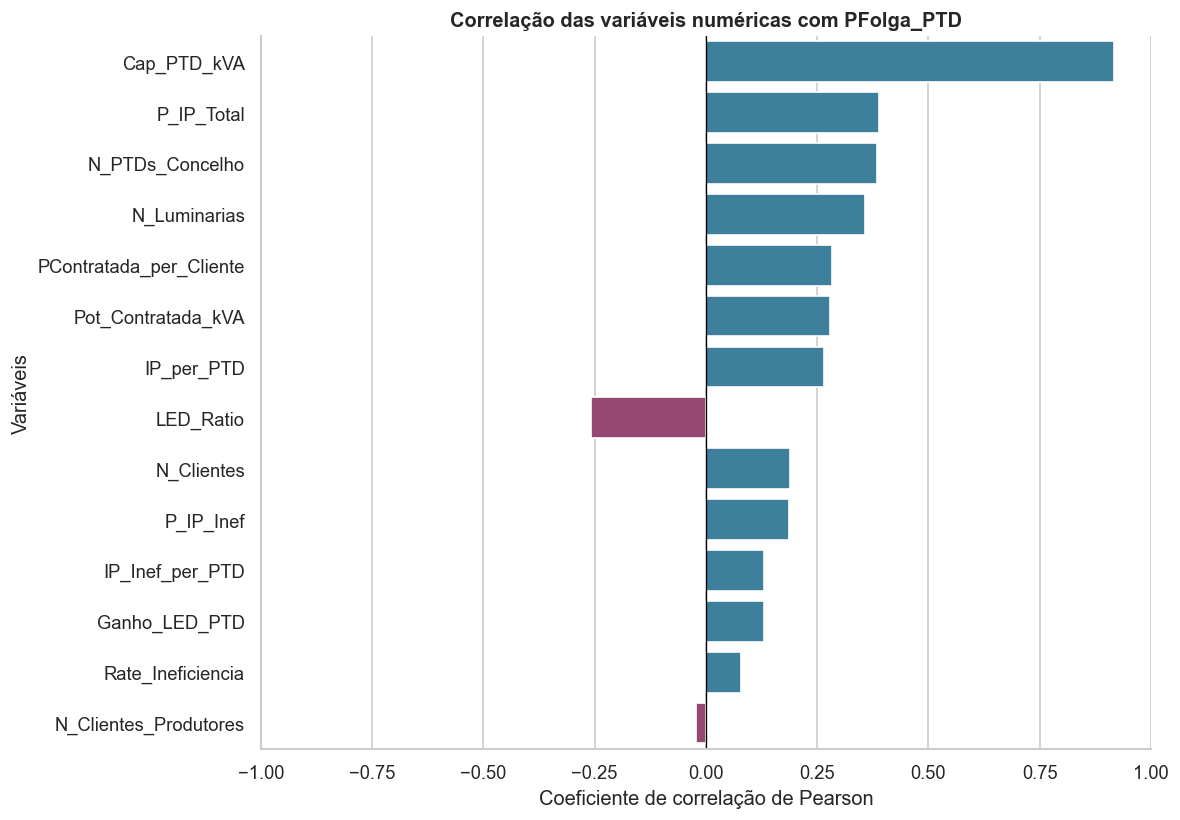

In [13]:
# Carregamento da base preparada de regressão criada no final da secção 4.1
regressao_path = PROCESSED_DIR / "dataset_regressao_preparado.csv"
base_regressao_modelacao = pd.read_csv(regressao_path)

print(
    f"Base de regressão carregada: "
    f"{base_regressao_modelacao.shape[0]} observações e "
    f"{base_regressao_modelacao.shape[1]} colunas"
)

print(
    f"Valores omissos na base de regressão: "
    f"{base_regressao_modelacao.isnull().sum().sum()}"
)

# Seleção das variáveis numéricas originais usadas na regressão
variaveis_numericas_regressao = [
    var for var in variaveis_selecionadas_base
    if var in base_regressao_imputada.columns
    and pd.api.types.is_numeric_dtype(base_regressao_imputada[var])
]

# Cálculo das correlações com a variável alvo
dados_correlacao = base_regressao_imputada[
    variaveis_numericas_regressao + [target_regressao]
]

correlacoes_pfolga = (
    dados_correlacao.corr(numeric_only=True)[target_regressao]
    .drop(target_regressao)
    .sort_values(key=abs, ascending=False)
)

display(correlacoes_pfolga.to_frame("Correlação com PFolga_PTD"))

# Gráfico das correlações
fig, ax = plt.subplots(figsize=(10, 7))

cores = [
    COR_PRINCIPAL if valor >= 0 else COR_SECUNDARIA
    for valor in correlacoes_pfolga.values
]

sns.barplot(
    x=correlacoes_pfolga.values,
    y=correlacoes_pfolga.index,
    palette=cores,
    hue=correlacoes_pfolga.index,
    legend=False,
    ax=ax
)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação das variáveis numéricas com PFolga_PTD", fontweight="bold")
ax.set_xlabel("Coeficiente de correlação de Pearson")
ax.set_ylabel("Variáveis")
ax.set_xlim(-1, 1)

sns.despine(ax=ax)
plt.tight_layout()

guardar_grafico(fig, "correlacao_pfolga_ptd_regressao.png")
plt.show()

A análise de correlação confirma que **`Cap_PTD_kVA`** é a variável com associação linear mais forte com `PFolga_PTD`, apresentando uma correlação positiva muito elevada. Este resultado é coerente com o problema em estudo, uma vez que PTD com maior capacidade instalada tendem a apresentar maior folga disponível.

As variáveis associadas à dimensão da infraestrutura, como `P_IP_Total`, `N_PTDs_Concelho` e `N_Luminarias`, apresentam correlações positivas moderadas. Isto sugere que zonas com maior infraestrutura elétrica e de iluminação pública tendem a estar associadas a maiores valores de folga por PTD.

A variável `LED_Ratio` apresenta uma correlação negativa moderada com `PFolga_PTD`, indicando que a relação entre eficiência da iluminação pública e folga disponível não é direta nem isolada, podendo depender de outros fatores da rede. Já `Rate_Ineficiencia` e `N_Clientes_Produtores` apresentam correlações muito reduzidas, pelo que a sua contribuição linear individual para explicar `PFolga_PTD` parece limitada.

Importa referir que a correlação mede apenas associação linear, não permitindo concluir relações de causalidade. Ainda assim, estes resultados ajudam a identificar variáveis relevantes para a modelação.

Com base nesta análise, **`Cap_PTD_kVA`** será usada como variável explicativa na regressão linear simples, por apresentar a associação linear mais forte com `PFolga_PTD` e uma interpretação técnica clara no contexto da capacidade disponível dos PTD.

### 4.2.2 Regressão linear simples com validação cruzada k-fold

A regressão linear simples permite modelar a relação entre uma variável explicativa e uma variável alvo contínua. Nesta etapa, pretende-se prever `PFolga_PTD` usando apenas uma variável explicativa.

Com base na análise de correlação anterior, foi selecionada a variável **`Cap_PTD_kVA`**, por apresentar a associação linear mais forte com `PFolga_PTD` (aproximadamente 0,916). Esta escolha também é coerente do ponto de vista técnico, uma vez que PTD com maior capacidade instalada tendem a apresentar maior folga disponível.

O desempenho do modelo será avaliado através de validação cruzada **k-fold** manual, com 5 subconjuntos. Em cada iteração, o modelo é treinado em quatro subconjuntos e avaliado no subconjunto restante, sendo calculadas as métricas **MAE**, **RMSE** e **R²**.

In [14]:
# Variável explicativa escolhida para a regressão linear simples
variavel_simples = "Cap_PTD_kVA"

# Usa-se a base imputada na escala original para obter uma função linear interpretável
X_simples = base_regressao_imputada[[variavel_simples]].copy()
y_simples = base_regressao_imputada[target_regressao].copy()

print(f"Variável explicativa utilizada: {variavel_simples}")
print(f"Variável alvo: {target_regressao}")
print(f"Número de observações: {X_simples.shape[0]}")
print(f"Valores omissos em X: {X_simples.isnull().sum().sum()}")
print(f"Valores omissos em y: {y_simples.isnull().sum()}")

Variável explicativa utilizada: Cap_PTD_kVA
Variável alvo: PFolga_PTD
Número de observações: 68963
Valores omissos em X: 0
Valores omissos em y: 0


In [15]:
# Validação cruzada k-fold manual
kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_folds_simples = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_simples), start=1):
    X_train = X_simples.iloc[train_idx]
    X_test = X_simples.iloc[test_idx]
    y_train = y_simples.iloc[train_idx]
    y_test = y_simples.iloc[test_idx]

    modelo_fold = LinearRegression()
    modelo_fold.fit(X_train, y_train)

    y_pred = modelo_fold.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_folds_simples.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

resultados_folds_simples = pd.DataFrame(resultados_folds_simples)

display(resultados_folds_simples.round(4))

resumo_regressao_linear_simples = pd.DataFrame({
    "Modelo": ["Regressão linear simples"],
    "Variável explicativa": [variavel_simples],
    "MAE médio": [resultados_folds_simples["MAE"].mean()],
    "Desvio padrão MAE": [resultados_folds_simples["MAE"].std()],
    "RMSE médio": [resultados_folds_simples["RMSE"].mean()],
    "Desvio padrão RMSE": [resultados_folds_simples["RMSE"].std()],
    "R² médio": [resultados_folds_simples["R²"].mean()]
})

display(resumo_regressao_linear_simples.round(4))


,Fold,MAE,RMSE,R²
0,1,50.8692,75.4987,0.8310
1,2,50.6930,74.6582,0.8318
2,3,51.1695,75.5031,0.8391
3,4,50.4508,74.5950,0.8469
4,5,50.5647,74.6071,0.8444


,Modelo,Variável explicativa,MAE médio,Desvio padrão MAE,RMSE médio,Desvio padrão RMSE,R² médio
0,Regressão linear simples,Cap_PTD_kVA,50.7494,0.2817,74.9724,0.483,0.8386


#### a) Função linear resultante


In [16]:
# Modelo final treinado com todos os dados para apresentar a equação estimada
modelo_linear_simples_final = LinearRegression()
modelo_linear_simples_final.fit(X_simples, y_simples)

b0 = modelo_linear_simples_final.intercept_
b1 = modelo_linear_simples_final.coef_[0]

print("Função linear resultante:")
print(f"PFolga_PTD = {b0:.4f} + {b1:.4f} × {variavel_simples}")

Função linear resultante:
PFolga_PTD = -32.1888 + 0.5937 × Cap_PTD_kVA


O coeficiente angular obtido é positivo, indicando que valores mais elevados de `Cap_PTD_kVA` estão associados a valores mais elevados de `PFolga_PTD`. Assim, por cada aumento de 1 kVA na capacidade instalada do PTD, o modelo estima um aumento médio de aproximadamente **0,5937 unidades** na folga de potência. Esta relação está de acordo com a correlação positiva forte observada no ponto anterior.

#### b) Reta de regressão e diagrama de dispersão


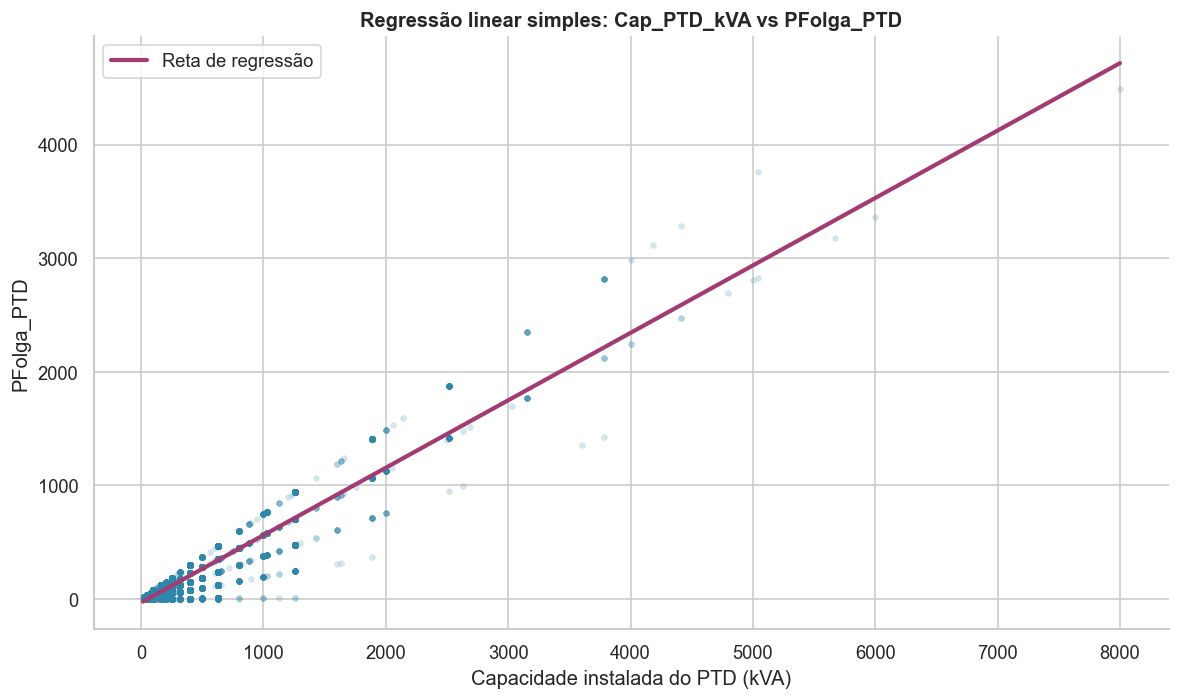

In [17]:
dados_grafico_simples = base_regressao_imputada[[variavel_simples, target_regressao]].copy()

x_reta = np.linspace(
    base_regressao_imputada[variavel_simples].min(),
    base_regressao_imputada[variavel_simples].max(),
    200
).reshape(-1, 1)
y_reta = modelo_linear_simples_final.predict(pd.DataFrame(x_reta, columns=[variavel_simples]))

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=dados_grafico_simples,
    x=variavel_simples,
    y=target_regressao,
    alpha=0.20,
    s=12,
    color=COR_PRINCIPAL,
    edgecolor=None,
    ax=ax
)

ax.plot(x_reta.ravel(), y_reta, color=COR_SECUNDARIA, linewidth=2.5, label="Reta de regressão")

ax.set_title("Regressão linear simples: Cap_PTD_kVA vs PFolga_PTD", fontweight="bold")
ax.set_xlabel("Capacidade instalada do PTD (kVA)")
ax.set_ylabel("PFolga_PTD")
ax.legend()
sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "regressao_linear_simples_cap_ptd_pfolga.png")
plt.show()


O diagrama de dispersão mostra uma relação positiva clara entre `Cap_PTD_kVA` e `PFolga_PTD`, confirmando que PTD com maior capacidade instalada tendem a apresentar maior folga de potência. A reta de regressão acompanha esta tendência geral.

No entanto, observa-se alguma dispersão em torno da reta e a presença de valores extremos, o que indica que uma única variável não explica totalmente a variabilidade da folga. Assim, embora `Cap_PTD_kVA` seja uma variável relevante, modelos com mais variáveis poderão captar melhor a complexidade do problema.

#### c) MAE e RMSE do modelo


O **MAE** representa o erro absoluto médio entre os valores reais e previstos, sendo interpretado na mesma unidade da variável alvo. O **RMSE** corresponde à raiz quadrada do erro quadrático médio e penaliza mais os erros elevados.

Com validação cruzada k-fold, a regressão linear simples obteve um **MAE médio de aproximadamente 50,75**, um **RMSE médio de aproximadamente 74,97** e um **R² médio de aproximadamente 0,839**. Este valor de R² indica que `Cap_PTD_kVA`, isoladamente, explica uma parte significativa da variação observada em `PFolga_PTD`.

Apesar do bom desempenho inicial, os erros obtidos e a dispersão observada no gráfico mostram que a folga disponível não depende apenas da capacidade instalada do PTD. Assim, justifica-se a aplicação de modelos com mais variáveis explicativas nas etapas seguintes.

### 4.2.3 Modelos de regressão com validação cruzada k-fold

Depois da regressão linear simples, procede-se ao desenvolvimento de modelos de regressão usando validação cruzada **k-fold**. Neste ponto serão avaliados diferentes modelos estudados na componente teórica, nomeadamente regressão linear múltipla, árvore de regressão, SVM e rede neuronal.

Cada modelo será analisado separadamente, mantendo as mesmas métricas de avaliação: **MAE**, **RMSE** e **R²**. A primeira abordagem considerada é a regressão linear múltipla.

#### a) Regressão linear múltipla

A regressão linear múltipla generaliza a regressão linear simples, usando várias variáveis explicativas para estimar uma variável alvo contínua. Neste caso, são utilizadas todas as variáveis explicativas da base preparada de regressão, incluindo variáveis numéricas standardizadas e variáveis categóricas codificadas por *one-hot encoding*.

Tal como no modelo anterior, a avaliação é feita através de validação cruzada **k-fold** manual com 5 divisões, calculando **MAE**, **RMSE** e **R²** em cada fold.

In [18]:
# Separação entre variáveis explicativas e variável alvo
X_multipla = base_regressao_modelacao.drop(columns=[target_regressao]).copy()
y_multipla = base_regressao_modelacao[target_regressao].copy()

print(f"Número de observações: {X_multipla.shape[0]}")
print(f"Número de variáveis explicativas: {X_multipla.shape[1]}")
print(f"Valores omissos em X: {X_multipla.isnull().sum().sum()}")
print(f"Valores omissos em y: {y_multipla.isnull().sum()}")

Número de observações: 68963
Número de variáveis explicativas: 41
Valores omissos em X: 0
Valores omissos em y: 0


In [19]:
# Validação cruzada k-fold manual para regressão linear múltipla
kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_folds_multipla = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_multipla), start=1):
    X_train = X_multipla.iloc[train_idx]
    X_test = X_multipla.iloc[test_idx]
    y_train = y_multipla.iloc[train_idx]
    y_test = y_multipla.iloc[test_idx]

    modelo_fold = LinearRegression()
    modelo_fold.fit(X_train, y_train)

    y_pred = modelo_fold.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_folds_multipla.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

resultados_folds_multipla = pd.DataFrame(resultados_folds_multipla)

display(resultados_folds_multipla.round(4))

resumo_regressao_linear_multipla = pd.DataFrame({
    "Modelo": ["Regressão linear múltipla"],
    "Nº variáveis explicativas": [X_multipla.shape[1]],
    "MAE médio": [resultados_folds_multipla["MAE"].mean()],
    "Desvio padrão MAE": [resultados_folds_multipla["MAE"].std()],
    "RMSE médio": [resultados_folds_multipla["RMSE"].mean()],
    "Desvio padrão RMSE": [resultados_folds_multipla["RMSE"].std()],
    "R² médio": [resultados_folds_multipla["R²"].mean()]
})

display(resumo_regressao_linear_multipla.round(4))


,Fold,MAE,RMSE,R²
0,1,34.8650,52.6697,0.9177
1,2,34.8767,52.1686,0.9179
2,3,34.9333,52.2223,0.9230
3,4,34.5340,52.4854,0.9242
4,5,35.0315,53.7782,0.9191


,Modelo,Nº variáveis explicativas,MAE médio,Desvio padrão MAE,RMSE médio,Desvio padrão RMSE,R² médio
0,Regressão linear múltipla,41,34.8481,0.1875,52.6648,0.6546,0.9204


In [20]:
# Modelo final treinado com todos os dados para analisar os coeficientes
modelo_linear_multipla_final = LinearRegression()
modelo_linear_multipla_final.fit(X_multipla, y_multipla)

coeficientes_multipla = pd.DataFrame({
    "Variável": X_multipla.columns,
    "Coeficiente": modelo_linear_multipla_final.coef_
})

coeficientes_multipla["Coeficiente absoluto"] = coeficientes_multipla["Coeficiente"].abs()
coeficientes_multipla = coeficientes_multipla.sort_values("Coeficiente absoluto", ascending=False)

display(coeficientes_multipla.head(10).round(4))

,Variável,Coeficiente,Coeficiente absoluto
0,Cap_PTD_kVA,209.8463,209.8463
3,N_Clientes,-38.0270,38.0270
1,Pot_Contratada_kVA,-23.3793,23.3793
40,Tipo Construtivo_Cabine subterrânea,-21.6062,21.6062
2,PContratada_per_Cliente,-17.1622,17.1622
32,Tipo Construtivo_Aéreo - A,15.6594,15.6594
9,N_Luminarias,-15.3574,15.3574
5,P_IP_Total,14.6752,14.6752
34,Tipo Construtivo_Aéreo - AS,13.6205,13.6205
10,N_PTDs_Concelho,8.2760,8.2760


A regressão linear múltipla apresenta melhor desempenho do que a regressão linear simples, reduzindo o **MAE** e o **RMSE**. Este resultado era esperado, uma vez que o modelo utiliza várias variáveis explicativas, incorporando informação sobre capacidade, clientes, potência contratada, iluminação pública e contexto regional.

O valor médio de **R²** também aumenta, indicando maior capacidade explicativa face ao modelo simples. No entanto, por se tratar de um modelo linear, continua limitado à representação de relações aproximadamente lineares entre as variáveis explicativas e `PFolga_PTD`.

A análise dos coeficientes sugere que `Cap_PTD_kVA` continua a ter um peso relevante no modelo. Como as variáveis numéricas foram standardizadas na base preparada, os coeficientes dessas variáveis podem ser comparados de forma mais direta em termos de magnitude. As variáveis categóricas codificadas por *one-hot encoding* devem ser interpretadas com maior cuidado, pois representam diferenças associadas a categorias específicas.

#### b) Árvore de regressão

A árvore de regressão cria divisões sucessivas nos dados com o objetivo de prever uma variável contínua. Ao contrário da regressão linear, este modelo não assume uma relação linear entre as variáveis explicativas e `PFolga_PTD`.

Nesta etapa são testados manualmente diferentes valores controlados de profundidade máxima. A melhor configuração é escolhida com base no menor **RMSE médio**, considerando também a interpretabilidade do modelo.

In [21]:
profundidades_arvore = [3, 5, 7, 10]

resultados_arvore = []

for profundidade in profundidades_arvore:
    resultados_folds = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_multipla), start=1):
        X_train = X_multipla.iloc[train_idx]
        X_test = X_multipla.iloc[test_idx]
        y_train = y_multipla.iloc[train_idx]
        y_test = y_multipla.iloc[test_idx]

        modelo_arvore = DecisionTreeRegressor(max_depth=profundidade, random_state=42)
        modelo_arvore.fit(X_train, y_train)

        y_pred = modelo_arvore.predict(X_test)

        resultados_folds.append({
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
            "R²": r2_score(y_test, y_pred)
        })

    resultados_folds = pd.DataFrame(resultados_folds)

    resultados_arvore.append({
        "Profundidade máxima": profundidade,
        "MAE médio": resultados_folds["MAE"].mean(),
        "RMSE médio": resultados_folds["RMSE"].mean(),
        "R² médio": resultados_folds["R²"].mean()
    })

resultados_arvore = pd.DataFrame(resultados_arvore)
display(resultados_arvore.round(4))

melhor_idx_arvore = resultados_arvore["RMSE médio"].idxmin()
melhor_profundidade_arvore = resultados_arvore.loc[melhor_idx_arvore, "Profundidade máxima"]

print(f"Melhor profundidade máxima: {melhor_profundidade_arvore}")

,Profundidade máxima,MAE médio,RMSE médio,R² médio
0,3,46.6165,74.4370,0.8410
1,5,36.2725,56.9388,0.9069
2,7,32.9087,53.5720,0.9176
3,10,32.1578,54.3760,0.9151


Melhor profundidade máxima: 7


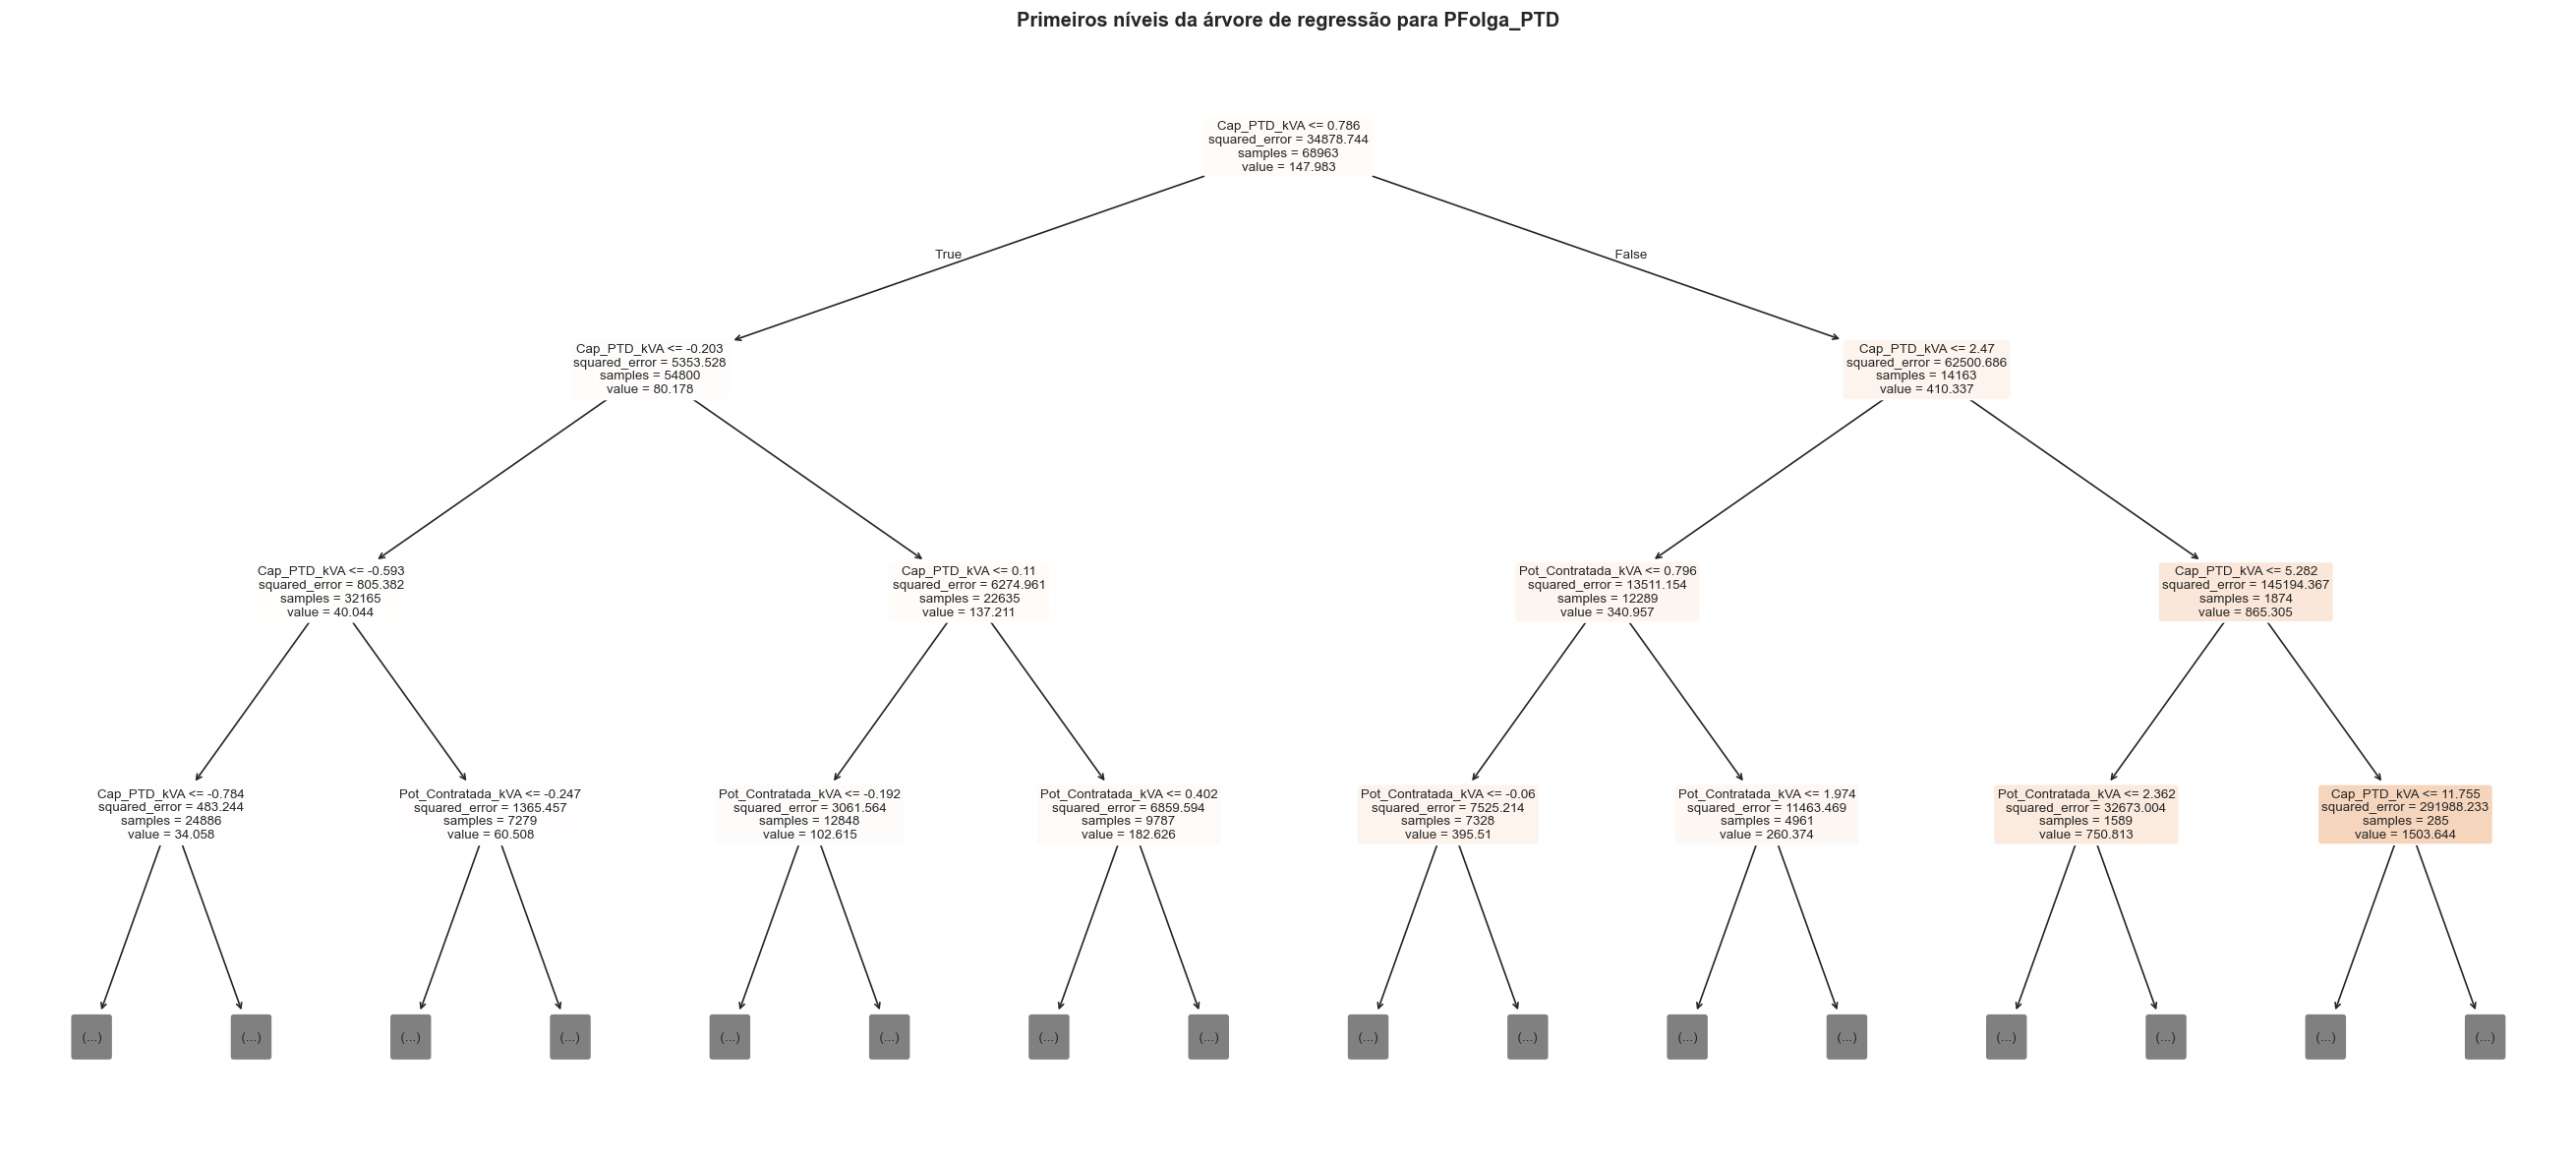

In [22]:
# Treino da árvore final com a melhor profundidade encontrada
modelo_arvore_final = DecisionTreeRegressor(max_depth=melhor_profundidade_arvore, random_state=42)
modelo_arvore_final.fit(X_multipla, y_multipla)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_arvore_final,
    feature_names=X_multipla.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax
)

ax.set_title("Primeiros níveis da árvore de regressão para PFolga_PTD", fontweight="bold")
plt.tight_layout()
guardar_grafico(fig, "arvore_regressao_pfolga.png")
plt.show()


A melhor árvore foi escolhida com base no menor RMSE médio entre as profundidades testadas. O modelo final foi treinado com essa profundidade, mas a visualização apresenta apenas os primeiros três níveis para manter o gráfico interpretável. Profundidades mais elevadas podem melhorar o ajustamento aos dados de treino, mas também aumentam o risco de sobreajustamento.

#### c) SVM com otimização manual do kernel

O modelo SVM para regressão procura estimar uma função capaz de aproximar os valores da variável alvo, controlando os erros através de uma margem. Nesta etapa são comparados manualmente os kernels `linear` e `rbf`, usando sempre o dataset completo.

A escolha do melhor kernel é feita com base no menor **RMSE médio** obtido em validação cruzada **k-fold** manual. O kernel polinomial não foi incluído nesta execução devido ao maior custo computacional no dataset completo, mantendo-se a comparação entre um kernel linear e um kernel não linear.

In [23]:
import time

kernels_svm = [
    {"kernel": "linear"},
    {"kernel": "rbf"}
]

resultados_svm = []

for config in kernels_svm:
    resultados_folds = []
    inicio_kernel = time.time()

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_multipla), start=1):
        inicio_fold = time.time()

        X_train = X_multipla.iloc[train_idx]
        X_test = X_multipla.iloc[test_idx]
        y_train = y_multipla.iloc[train_idx]
        y_test = y_multipla.iloc[test_idx]

        modelo_svm = SVR(
            kernel=config["kernel"],
            C=1.0,
            epsilon=0.1,
            gamma="scale"
        )

        modelo_svm.fit(X_train, y_train)
        y_pred = modelo_svm.predict(X_test)

        resultados_folds.append({
            "Fold": fold,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
            "R²": r2_score(y_test, y_pred),
            "Tempo (s)": time.time() - inicio_fold
        })

    resultados_folds = pd.DataFrame(resultados_folds)

    resultados_svm.append({
        "Kernel": config["kernel"],
        "MAE médio": resultados_folds["MAE"].mean(),
        "RMSE médio": resultados_folds["RMSE"].mean(),
        "R² médio": resultados_folds["R²"].mean(),
        "Tempo total (s)": time.time() - inicio_kernel
    })

resultados_svm = pd.DataFrame(resultados_svm)
display(resultados_svm.round(4))

melhor_idx_svm = resultados_svm["RMSE médio"].idxmin()
melhor_kernel_svm = resultados_svm.loc[melhor_idx_svm, "Kernel"]

print(f"Melhor kernel SVM: {melhor_kernel_svm}")

,Kernel,MAE médio,RMSE médio,R² médio,Tempo total (s)
0,linear,33.2890,54.5309,0.9147,337.1222
1,rbf,44.9901,110.9477,0.6470,544.7327


Melhor kernel SVM: linear


O kernel com menor **RMSE médio** é selecionado como a melhor configuração SVM nesta comparação manual. Como o dataset completo é usado em todos os folds, os resultados são diretamente comparáveis com os restantes modelos de regressão.

Esta otimização deve ser interpretada no contexto dos kernels testados (`linear` e `rbf`), escolhidos por representarem uma alternativa linear e uma alternativa não linear, mantendo o tempo de execução viável no dataset completo.

#### d) Rede neuronal com otimização estruturada

As redes neuronais permitem modelar relações não lineares entre as variáveis explicativas e a variável alvo. Nesta etapa são ensaiadas três configurações moderadas, variando a profundidade da rede, o número de neurónios por camada, a regularização L2 (`alpha`) e a *learning rate*.

A avaliação é feita com o dataset completo e validação cruzada **k-fold** manual. Em todos os modelos é usado `early_stopping=True`, com 15% dos dados de treino reservados internamente para validação, de forma a reduzir o risco de sobreajustamento e controlar o número de iterações de treino.

In [24]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

configuracoes_rede = [
    {"Nome": "1 camada", "Camadas": (32,), "Alpha L2": 0.0001, "Learning rate": 0.001},
    {"Nome": "2 camadas", "Camadas": (64, 32), "Alpha L2": 0.0001, "Learning rate": 0.001},
    {"Nome": "2 camadas com L2 maior", "Camadas": (64, 32), "Alpha L2": 0.01, "Learning rate": 0.001}
]

resultados_rede = []

for config in configuracoes_rede:
    resultados_folds = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_multipla), start=1):
        X_train = X_multipla.iloc[train_idx]
        X_test = X_multipla.iloc[test_idx]
        y_train = y_multipla.iloc[train_idx]
        y_test = y_multipla.iloc[test_idx]

        modelo_rede = MLPRegressor(
            hidden_layer_sizes=config["Camadas"],
            activation="relu",
            solver="adam",
            alpha=config["Alpha L2"],
            learning_rate_init=config["Learning rate"],
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=10,
            random_state=42
        )

        modelo_rede.fit(X_train, y_train)
        y_pred = modelo_rede.predict(X_test)

        resultados_folds.append({
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
            "R²": r2_score(y_test, y_pred)
        })

    resultados_folds = pd.DataFrame(resultados_folds)

    resultados_rede.append({
    "Configuração": config["Nome"],
    "Camadas": str(config["Camadas"]),
    "Alpha L2": config["Alpha L2"],
    "Learning rate": config["Learning rate"],
    "MAE médio": resultados_folds["MAE"].mean(),
    "Desvio padrão MAE": resultados_folds["MAE"].std(),
    "RMSE médio": resultados_folds["RMSE"].mean(),
    "Desvio padrão RMSE": resultados_folds["RMSE"].std(),
    "R² médio": resultados_folds["R²"].mean()
})

resultados_rede = pd.DataFrame(resultados_rede)
display(resultados_rede.round(4))

melhor_idx_rede = resultados_rede["RMSE médio"].idxmin()
melhor_configuracao_rede = resultados_rede.loc[melhor_idx_rede, "Configuração"]

print(f"Melhor configuração de rede neuronal: {melhor_configuracao_rede}")


,Configuração,Camadas,Alpha L2,Learning rate,MAE médio,Desvio padrão MAE,RMSE médio,Desvio padrão RMSE,R² médio
0,1 camada,"(32,)",0.0001,0.001,31.7841,0.1955,50.1553,0.4560,0.9278
1,2 camadas,"(64, 32)",0.0001,0.001,30.6969,0.2154,48.9435,0.6221,0.9312
2,2 camadas com L2 maior,"(64, 32)",0.0100,0.001,30.7087,0.1912,49.0183,0.6933,0.9310


Melhor configuração de rede neuronal: 2 camadas


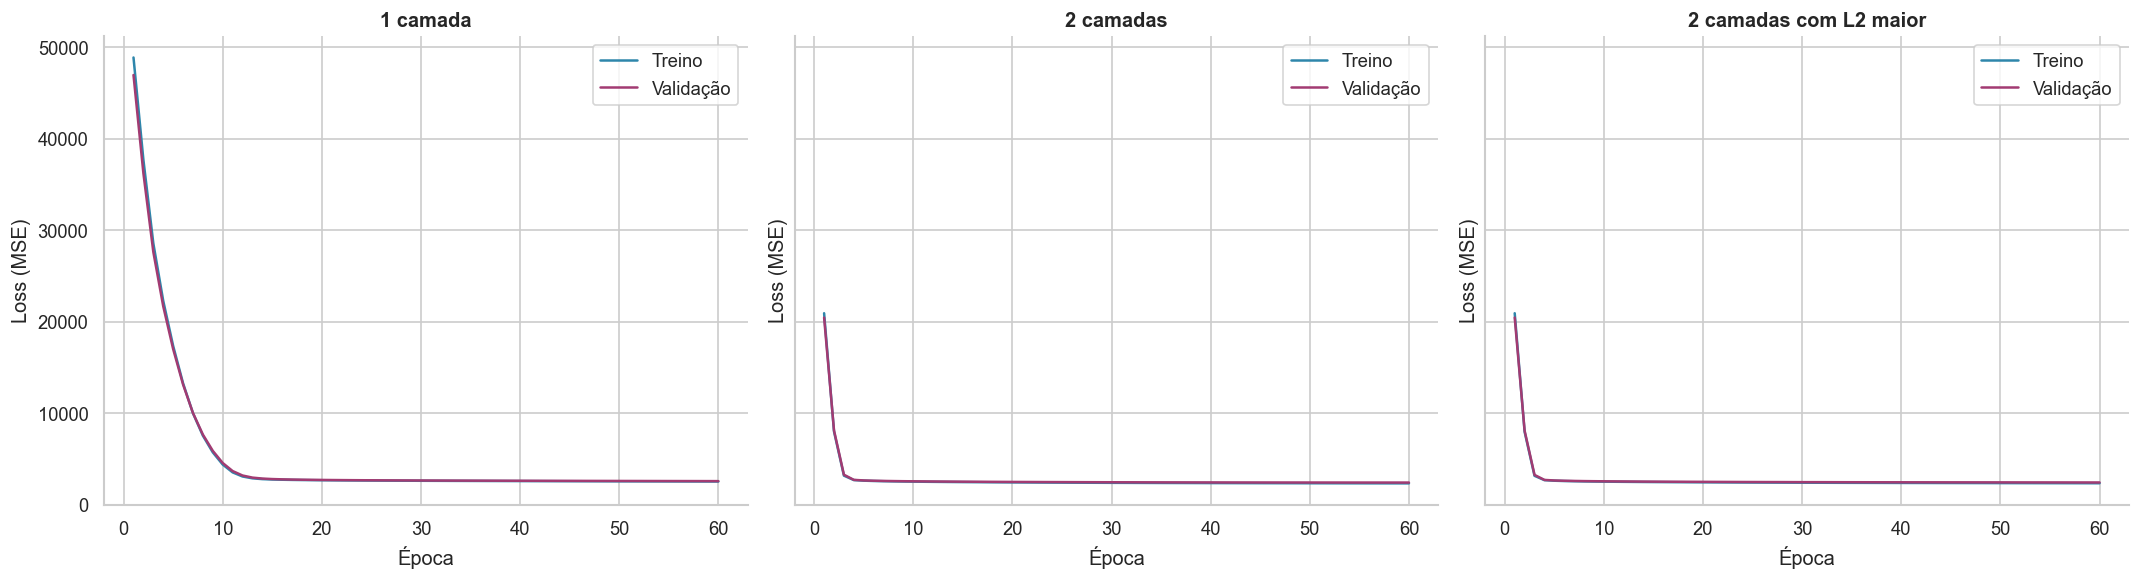

In [25]:
# Divisão treino/validação usada apenas para representar as curvas de loss
X_treino_curva, X_validacao_curva, y_treino_curva, y_validacao_curva = train_test_split(
    X_multipla, y_multipla, test_size=0.2, random_state=42
)

historico_loss_redes = []

for config in configuracoes_rede:
    modelo_curva = MLPRegressor(
        hidden_layer_sizes=config["Camadas"],
        activation="relu",
        solver="adam",
        alpha=config["Alpha L2"],
        learning_rate_init=config["Learning rate"],
        max_iter=1,
        warm_start=True,
        random_state=42
    )

    melhor_loss_validacao = np.inf
    epocas_sem_melhoria = 0
    paciencia = 8

    # Treino por épocas com warm_start para guardar a evolução da loss
    for epoca in range(1, 61):
        modelo_curva.fit(X_treino_curva, y_treino_curva)

        pred_treino = modelo_curva.predict(X_treino_curva)
        pred_validacao = modelo_curva.predict(X_validacao_curva)

        loss_treino = mean_squared_error(y_treino_curva, pred_treino)
        loss_validacao = mean_squared_error(y_validacao_curva, pred_validacao)

        historico_loss_redes.append({
            "Configuração": config["Nome"],
            "Época": epoca,
            "Loss treino": loss_treino,
            "Loss validação": loss_validacao
        })

        if loss_validacao < melhor_loss_validacao:
            melhor_loss_validacao = loss_validacao
            epocas_sem_melhoria = 0
        else:
            epocas_sem_melhoria += 1

        if epocas_sem_melhoria >= paciencia:
            break

historico_loss_redes = pd.DataFrame(historico_loss_redes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, config in zip(axes, configuracoes_rede):
    dados_config = historico_loss_redes[
        historico_loss_redes["Configuração"] == config["Nome"]
    ]

    ax.plot(dados_config["Época"], dados_config["Loss treino"], label="Treino", color=COR_PRINCIPAL)
    ax.plot(dados_config["Época"], dados_config["Loss validação"], label="Validação", color=COR_SECUNDARIA)

    ax.set_title(config["Nome"], fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss (MSE)")
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "curvas_loss_redes_neuronais_regressao.png")
plt.show()

As redes com duas camadas têm maior capacidade de modelação do que a rede com apenas uma camada, podendo captar relações não lineares mais complexas. A comparação entre as duas configurações com arquitetura `(64, 32)` permite avaliar o efeito da regularização L2.

A regularização L2 penaliza pesos demasiado elevados e pode reduzir o risco de sobreajustamento. A *learning rate* foi mantida em 0,001 nas três configurações, permitindo comparar sobretudo o efeito da arquitetura e da regularização.

As curvas de loss permitem analisar a evolução do erro de treino e validação ao longo das épocas. Quando a loss de treino continua a diminuir enquanto a loss de validação estabiliza ou aumenta, existem sinais de **overfitting**. O uso de *early stopping* permite interromper o treino quando a validação deixa de melhorar, reduzindo treino desnecessário e ajudando a controlar o sobreajustamento.

### 4.2.4 Comparação dos modelos de regressão

Nesta secção são comparados os modelos de regressão desenvolvidos anteriormente para prever `PFolga_PTD`. A comparação é feita principalmente com base no **MAE** e no **RMSE**, uma vez que estas métricas quantificam diretamente o erro de previsão.

Valores mais baixos de **MAE** e **RMSE** indicam melhor desempenho. O **R²** é apresentado como métrica complementar, permitindo avaliar a proporção da variabilidade de `PFolga_PTD` explicada pelo modelo.


In [26]:
# Construção da tabela comparativa com os resultados já obtidos
melhor_arvore = resultados_arvore.loc[resultados_arvore["RMSE médio"].idxmin()]
melhor_svm = resultados_svm.loc[resultados_svm["RMSE médio"].idxmin()]
melhor_rede = resultados_rede.loc[resultados_rede["RMSE médio"].idxmin()]

comparacao_modelos_regressao = pd.DataFrame([
    {
        "Modelo": "Regressão linear simples",
        "Configuração": variavel_simples,
        "MAE médio": resumo_regressao_linear_simples.loc[0, "MAE médio"],
        "RMSE médio": resumo_regressao_linear_simples.loc[0, "RMSE médio"],
        "R² médio": resumo_regressao_linear_simples.loc[0, "R² médio"]
    },
    {
        "Modelo": "Regressão linear múltipla",
        "Configuração": f"{X_multipla.shape[1]} variáveis explicativas",
        "MAE médio": resumo_regressao_linear_multipla.loc[0, "MAE médio"],
        "RMSE médio": resumo_regressao_linear_multipla.loc[0, "RMSE médio"],
        "R² médio": resumo_regressao_linear_multipla.loc[0, "R² médio"]
    },
    {
        "Modelo": "Árvore de regressão",
        "Configuração": f"profundidade {melhor_profundidade_arvore}",
        "MAE médio": melhor_arvore["MAE médio"],
        "RMSE médio": melhor_arvore["RMSE médio"],
        "R² médio": melhor_arvore["R² médio"]
    },
    {
        "Modelo": "SVM",
        "Configuração": f"kernel {melhor_kernel_svm}",
        "MAE médio": melhor_svm["MAE médio"],
        "RMSE médio": melhor_svm["RMSE médio"],
        "R² médio": melhor_svm["R² médio"]
    },
    {
        "Modelo": "Rede neuronal",
        "Configuração": melhor_configuracao_rede,
        "MAE médio": melhor_rede["MAE médio"],
        "RMSE médio": melhor_rede["RMSE médio"],
        "R² médio": melhor_rede["R² médio"]
    }
])

comparacao_modelos_regressao = comparacao_modelos_regressao.sort_values("RMSE médio").reset_index(drop=True)
display(comparacao_modelos_regressao.round(4))


,Modelo,Configuração,MAE médio,RMSE médio,R² médio
0,Rede neuronal,2 camadas,30.6969,48.9435,0.9312
1,Regressão linear múltipla,41 variáveis explicativas,34.8481,52.6648,0.9204
2,Árvore de regressão,profundidade 7,32.9087,53.5720,0.9176
3,SVM,kernel linear,33.2890,54.5309,0.9147
4,Regressão linear simples,Cap_PTD_kVA,50.7494,74.9724,0.8386


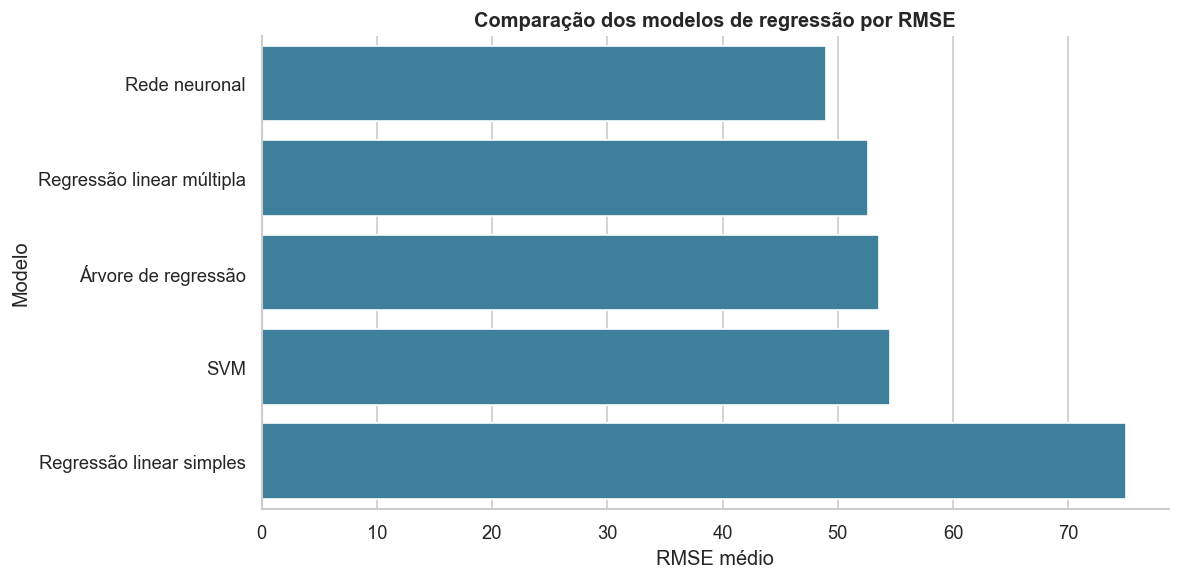

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=comparacao_modelos_regressao,
    x="RMSE médio",
    y="Modelo",
    color=COR_PRINCIPAL,
    ax=ax
)

ax.set_title("Comparação dos modelos de regressão por RMSE", fontweight="bold")
ax.set_xlabel("RMSE médio")
ax.set_ylabel("Modelo")
sns.despine(ax=ax)

plt.tight_layout()
guardar_grafico(fig, "comparacao_modelos_regressao_rmse.png")
plt.show()


In [28]:
# Variáveis mais relevantes segundo a regressão linear múltipla
top_variaveis_regressao_multipla = (
    coeficientes_multipla
    .sort_values("Coeficiente absoluto", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_variaveis_regressao_multipla.round(4))

# Variáveis mais relevantes segundo a árvore de regressão
importancias_arvore = pd.DataFrame({
    "Variável": X_multipla.columns,
    "Importância": modelo_arvore_final.feature_importances_
})

top_variaveis_arvore = (
    importancias_arvore
    .sort_values("Importância", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_variaveis_arvore.round(4))


,Variável,Coeficiente,Coeficiente absoluto
0,Cap_PTD_kVA,209.8463,209.8463
1,N_Clientes,-38.0270,38.0270
2,Pot_Contratada_kVA,-23.3793,23.3793
3,Tipo Construtivo_Cabine subterrânea,-21.6062,21.6062
4,PContratada_per_Cliente,-17.1622,17.1622
5,Tipo Construtivo_Aéreo - A,15.6594,15.6594
6,N_Luminarias,-15.3574,15.3574
7,P_IP_Total,14.6752,14.6752
8,Tipo Construtivo_Aéreo - AS,13.6205,13.6205
9,N_PTDs_Concelho,8.2760,8.2760


,Variável,Importância
0,Cap_PTD_kVA,0.9236
1,Pot_Contratada_kVA,0.0676
2,PContratada_per_Cliente,0.0035
3,N_Clientes,0.0032
4,P_IP_Inef,0.0007
5,IP_per_PTD,0.0004
6,Rate_Ineficiencia,0.0003
7,Distrito_Porto,0.0002
8,N_Clientes_Produtores,0.0002
9,Distrito_Viana do Castelo,0.0001


A comparação mostra que a **rede neuronal** apresentou o melhor desempenho global, por obter o menor RMSE médio e o maior R² médio entre os modelos avaliados. Este resultado sugere que a rede conseguiu captar relações mais complexas entre as variáveis explicativas e `PFolga_PTD`.

A **regressão linear múltipla**, a **árvore de regressão** e o **SVM linear** apresentaram desempenhos relativamente próximos. A regressão linear múltipla obteve um RMSE ligeiramente inferior ao da árvore e do SVM, mostrando que a combinação linear das variáveis explicativas já representa bem grande parte da variação de `PFolga_PTD`.

A **regressão linear simples** teve o pior desempenho, o que é esperado, uma vez que utiliza apenas `Cap_PTD_kVA` como variável explicativa. Apesar de esta variável ter forte associação com `PFolga_PTD`, a inclusão de outras variáveis permite reduzir os erros de previsão.

Relativamente à relevância das variáveis, `Cap_PTD_kVA` destaca-se como a variável mais importante, tanto na regressão linear múltipla como na árvore de regressão. Também surgem como relevantes variáveis como `Pot_Contratada_kVA`, `N_Clientes`, `PContratada_per_Cliente`, `N_Luminarias` e `P_IP_Total`, dependendo do modelo analisado.

As variáveis categóricas codificadas por *one-hot encoding* devem ser interpretadas com cuidado, uma vez que cada coluna representa uma categoria específica e não uma variável contínua diretamente comparável com as restantes.